# Dataset of Sea animal Coursework

## Project Overview

This project explores sea animals and exploring all 16 animals 

We explore the following

1. **Baseliness CNN** - A convolutional neural network built 
2. **Transfer Learning Model** - MobileNetv2, ResNet50 and Efficientnetv2
3. **Fine-tuning** - Unfreezing layers to improve the pretrained models 

The dataset have over 8,000 images in 16 classes

## Experiment

- **Small data experiments** (640 images): Train model with limited data
- **Full data experiments** (6,145 images):Train the tain
- **Fine-tuning experiments**: Adapt pretrained features

#### Import Packages

In [ ]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
AUTOTUNE = tf.data.AUTOTUNE # Optimize data to reduce gpu time

#### Load the dataset

In [53]:
data_dir = "/home/bello_the_great/Downloads/ml_cw/COP508_Sea_Animal_dataset"

In [54]:
# img size

IMG_SIZE  = (224, 224, )
Batch_size = 32
SEED = 42

- Standard for all images 224 x 224. This will not to resize the images

In [55]:
SEED

42

#### Split the data

In [56]:

# Loading the training data

train_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.3, # this split the data into 70 training and 30 testi
    subset = "training",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = Batch_size,
)

# The remaining 30 percent is testing data

val_test_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.3,
    subset = "validation",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = Batch_size
)
class_names = train_data.class_names
numclass = len(class_names)
class_names

Found 8778 files belonging to 16 classes.
Using 6145 files for training.
Found 8778 files belonging to 16 classes.
Using 2633 files for validation.


['Corals',
 'Crabs',
 'Dolphin',
 'Eel',
 'Jelly Fish',
 'Lobster',
 'Nudibranchs',
 'Octopus',
 'Puffers',
 'Sea Rays',
 'Seahorse',
 'Seal',
 'Sharks',
 'Squid',
 'Starfish',
 'Whale']

- Spliting the data 70 and 30 

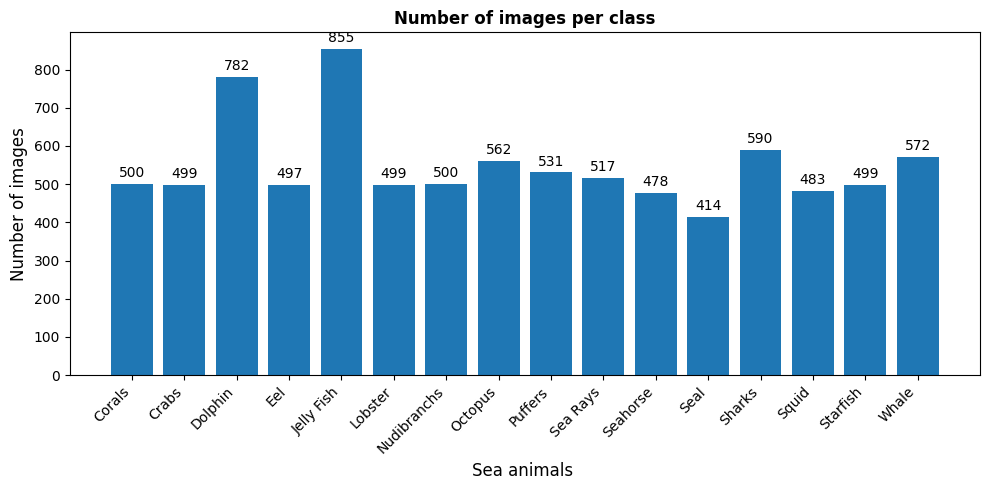

In [75]:
# display number of img per class

import os

image_count = []

for class_name in class_names:
    path_c = os.path.join(data_dir, class_name)
    if os.path.exists(path_c):
        count = len([ f for f in os.listdir(path_c) if f.endswith(('.jpg', '.png', '.jpeg'))])
        image_count.append(count)
plt.figure(figsize = (10, 5))
plt.bar(class_names, image_count,)
plt.title('Number of images per class', fontsize=12,  fontweight='bold')
plt.xlabel('Sea animals ', fontsize = 12)
plt.ylabel('Number of images', fontsize = 12)
plt.xticks(rotation = 45, ha='right')

for i, count in enumerate(image_count):
    plt.text(i, count + 10, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

- This shows Number of images in class

- Highest is 855 which is Jellyfish

- Lowest is seal

- This will cost imbalnce when training

#### Split it into val and test data

In [76]:
val_test_batches = tf.data.experimental.cardinality(val_test_data)
val_batches = val_test_batches // 2
test_batches = val_test_batches - val_batches

val_data = val_test_data.take(val_batches)
test_data = val_test_data.skip(val_batches)

In [77]:
print("train_data:", tf.data.experimental.cardinality(train_data).numpy())

train_data: 193


In [78]:
print("val_data:", tf.data.experimental.cardinality(val_data).numpy())

val_data: 41


In [61]:
print("test_data:", tf.data.experimental.cardinality(test_data).numpy())

test_data: 42


In [79]:
# to improve performance

train_data = train_data.shuffle(1000).prefetch(buffer_size = AUTOTUNE)
val_data = val_data.prefetch(buffer_size = AUTOTUNE)
test_data = test_data.prefetch(buffer_size = AUTOTUNE)

#### Display of IMG

2026-01-10 19:02:01.652502: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:02:01.652594: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB
2026-01-10 19:02:02.261300: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-10 19:02:02.261362: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


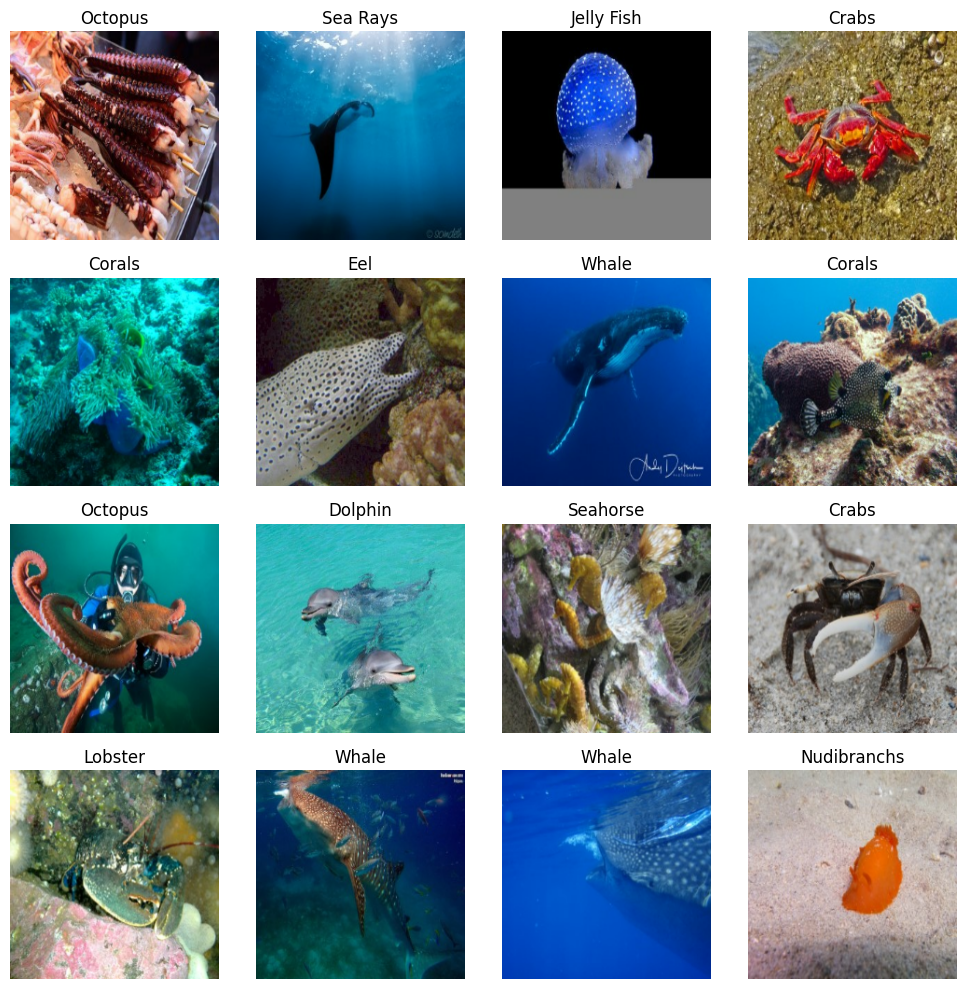

In [80]:
# show 16 img from the train set

plt.figure(figsize = (10, 10))
for images, labels in train_data.take(1):
  for i in range(16): # change to 16 img
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8")) # NB need to put uint8 to covert it to rgb
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

#### Create the small dataset and full dataset

In [81]:
small_train_batch = 20 # training set
small_val_batch = 10 # validation set

# quick training to see result

small_train_data = train_data.take(small_train_batch)
small_val_data = val_data.take(small_val_batch)

# Full dataset for final evaluation

full_train_data = train_data
full_val_data = val_data
full_test_data = test_data

#### History Plot and Data Augmentation

In [ ]:
# Data Augmentation logic
data_augu = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ], name = "data_augmentation"
)

# Graph of accuarcy and loss

def plot_train_hist(history, title_prefix=""):

    ''' Plot training and validation accuary and loss curves'''

    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(12, 4))

    # Accuracy Plot

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, 'bo-', label = ' Training accuary')
    plt.plot(epochs, val_acc, 'r-', label = ' Validation accuary')
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss plot

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, 'bo-', label = ' Training loss')
    plt.plot(epochs, val_loss, 'r-', label = ' Validation loss')
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

- Plotting the graph of training the model

- Data augmentation is implemented to fix some issues of the images like resolution, flip and rotation

####  classification report and Confusion layout

In [ ]:
from matplotlib import cm
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score

def eval_test(model, test_data, class_name, name = "model"):
    ''' Evaluate a trained model to test and display the following:
    - Test Accuary and loss
    - Classification report (recall, f1 and precison)
    - confusion matrix
    '''

    # Evaluate the test dataset

    test_loss, test_acc = model.evaluate(full_test_data, verbose= 1)
    print(f"{name} - Test accuracy: {test_acc*100:.2f}%, Test loss: {test_loss:.4f}")

    # True and predicted label
    y_true = []
    y_pred = []

    for images, labels in full_test_data:
        predictions = model.predict(images, verbose= 0)
        predicted_label = np.argmax(predictions, axis = 1)
        y_pred.extend(predicted_label)
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Classification Report
    print(f"\n{'='*70}")
    print(f"{name} - Classification Report")
    print(f"\n{'='*70}")
    print(classification_report(y_true, y_pred,
                                target_names=class_names, digits=4))
    
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True,
                fmt='d', cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title(f"Confusion matrix - {name}", fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Making a table to read the data better

    # Metric Table

    precision, recall, f1, _support= precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)),
        zero_division=0 )

    accuracy = accuracy_score(y_true, y_pred)

    metrics_df = pd.DataFrame({
        'Class': class_names,
        'Precision': np.round(precision, 4),
        'Recall': np.round(recall, 4),
        'F1-score': np.round(f1, 4),
        'Support': _support
    })

    print(f"\n{name} - Metrics Table")
    print(metrics_df.to_string(index=False))

    # Overall Metrics

    summary_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Weighted Precision', 'Weighted Recall', 'Weighted F1-score'],
        'Score': [
            round(accuracy, 4),
            round(np.average(precision, weights=_support), 4),
            round(np.average(recall, weights=_support), 4),
            round(np.average(f1, weights=_support), 4)
        ]
    })


    print(f"\n{name} - Overall Metrics")
    print(summary_df.to_string(index=False))
    print(f"{'='}\n")

    return metrics_df, summary_df

- This will display classification report of recall, f1-score, accuarcy and support

- Will also show confusion matrix

- Will create a table to see data side by side to be easier

In [84]:
print(IMG_SIZE + (3,))

(224, 224, 3)


## Baseline CNN : Model Creation

In [85]:
def cnn_model(input_shape = IMG_SIZE + (3,), num_classes = numclass):
  ''' A CNN Model will ne used as a baseline model to
  - rescale pixel img to 0,1
  - uses data augmentation
  '''

  # layer for rbg img
  inputs = keras.Input(shape = input_shape, name="input_image")

  #data
  x = data_augu(inputs)

  #change pixel to [0, 1]
  x = layers.Rescaling(1.0/255)(x)

  #convolutional layers and pooling blocks
  x = layers.Conv2D(filters = 32, kernel_size = 3, activation = "relu")(x)
  x = layers.MaxPooling2D()(x)

  x = layers.Conv2D(filters = 64, kernel_size = 3, activation = "relu")(x)
  x = layers.MaxPooling2D()(x)

  x = layers.Conv2D(filters = 128, kernel_size = 3, activation = "relu")(x)
  x = layers.MaxPooling2D()(x)

  # dense layers
  x = layers.Flatten()(x)
  x =layers.Dropout(0.5)(x)
  x = layers.Dense(128, activation = "relu")(x)
  x = layers.Dropout(0.5)(x)

  # output layer with softmax
  outputs = layers.Dense(num_classes, activation = "softmax", name="predictions")(x)

  model = keras.Model(inputs, outputs, name="baseline_cnn")
  return model

#### CNN Model on small dataset

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,171,024 (42.61 MB)

 Trainable params: 11,171,024 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.2859 - loss: 2.2206 - val_accuracy: 0.3094 - val_loss: 2.1538
Epoch 24/30


2026-01-10 19:03:14.909633: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:03:14.911077: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


 3/20 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.2760 - loss: 2.2135

2026-01-10 19:03:15.525799: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-10 19:03:15.525873: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.2672 - loss: 2.2143 - val_accuracy: 0.3063 - val_loss: 2.1335
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 19.


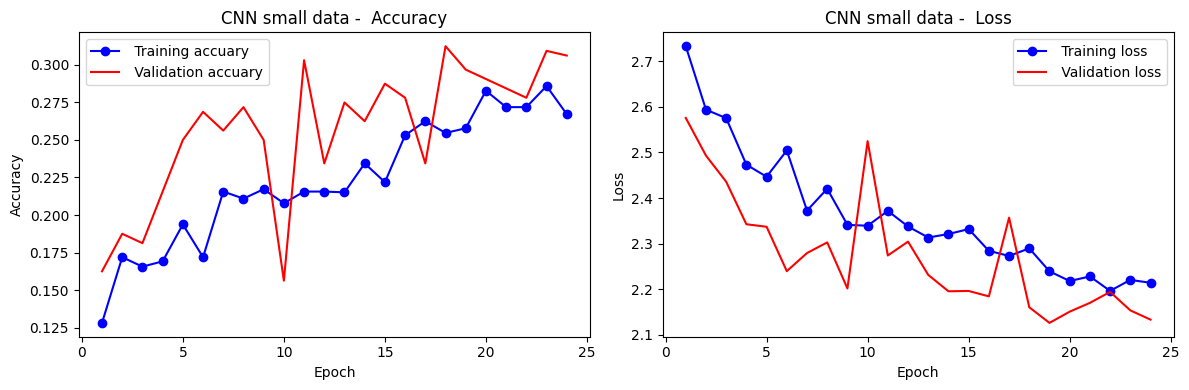

In [86]:
from tensorflow.keras.callbacks import EarlyStopping

base_model_sm = cnn_model()
base_model_sm.summary()

base_model_sm.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    verbose=1,
    restore_best_weights=True
)


base_model_sm_history = base_model_sm.fit(
    small_train_data,
    validation_data = small_val_data,
    callbacks = [early_stop],
    epochs = 30,
    verbose =1
)

plot_train_hist(base_model_sm_history, title_prefix="CNN small data - ")

2026-01-10 19:04:26.717973: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-10 19:04:26.957592: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:04:26.957616: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB
2026-01-10 19:04:30.137203: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Cnn - small dataset - Classification Report

              precision    recall  f1-score   support

      Corals     0.1695    0.5000    0.2532        60
       Crabs     0.2241    0.9306    0.3612        72
     Dolphin     0.2524    0.7290    0.3750       107
         Eel     0.2500    0.1222    0.1642        90
  Jelly Fish     0.6250    0.5597    0.5906       134
     Lobster     0.2000    0.0139    0.0260        72
 Nudibranchs     0.2308    0.0517    0.0845        58
     Octopus     0.1509    0.0889    0.1119        90
     Puffers     0.1111    0.0449    0.0640        89
    Sea Rays     0.1136    0.0641    0.0820        78
    Seahorse     0.2222    0.1067    0.1441        75
        Seal     0.3077    0.1356    0.1882        59
      Sharks     0.4286    0.0938    0.1538        96
       Squid     0.4762    0.1220    0.1942        82
    Starfish     0.3636    0.2740    0.3125        73
       Whale     0.3226    0.2326    0.2703        86

    accuracy                      

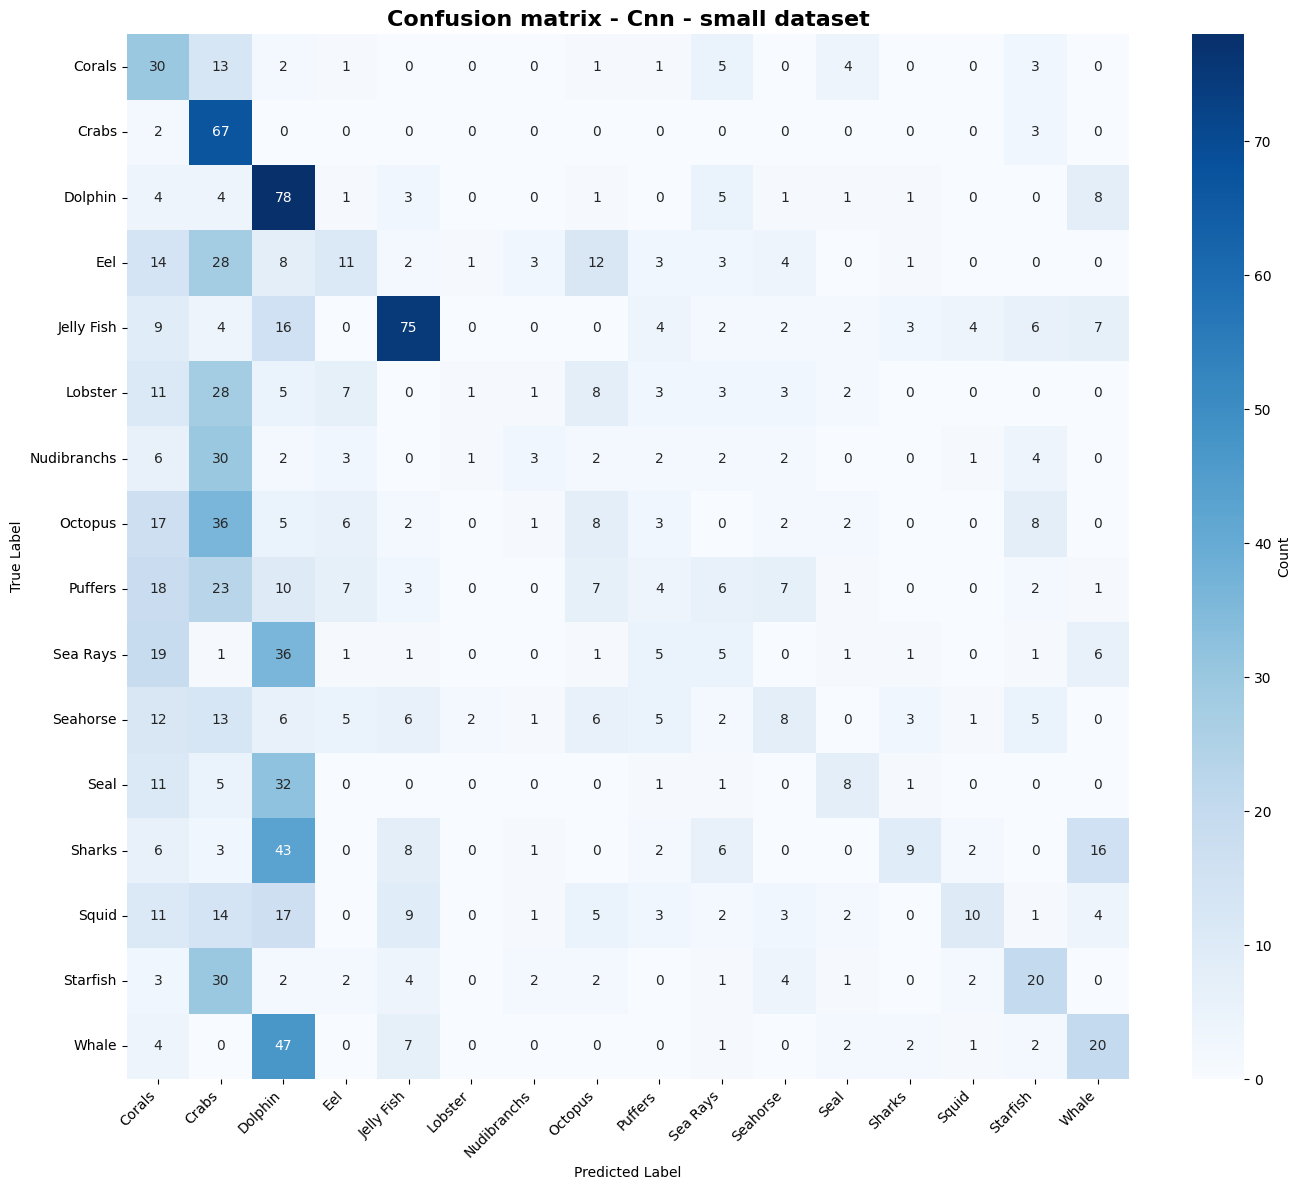


Cnn - small dataset - Metrics Table
      Class  Precision  Recall  F1-score  Support
     Corals     0.1695  0.5000    0.2532       60
      Crabs     0.2241  0.9306    0.3612       72
    Dolphin     0.2524  0.7290    0.3750      107
        Eel     0.2500  0.1222    0.1642       90
 Jelly Fish     0.6250  0.5597    0.5906      134
    Lobster     0.2000  0.0139    0.0260       72
Nudibranchs     0.2308  0.0517    0.0845       58
    Octopus     0.1509  0.0889    0.1119       90
    Puffers     0.1111  0.0449    0.0640       89
   Sea Rays     0.1136  0.0641    0.0820       78
   Seahorse     0.2222  0.1067    0.1441       75
       Seal     0.3077  0.1356    0.1882       59
     Sharks     0.4286  0.0938    0.1538       96
      Squid     0.4762  0.1220    0.1942       82
   Starfish     0.3636  0.2740    0.3125       73
      Whale     0.3226  0.2326    0.2703       86

Cnn - small dataset - Overall Metrics
            Metric  Score
          Accuracy 0.2702
Weighted Precision 0.2

In [ ]:
# Evalaute model

summary_cnn_small = eval_test(
    base_model_sm, full_test_data, class_names, name= 'Cnn - small dataset')

- This perform poorly due to the limited amount of data. Early spotting shows that the best was at 19 epochs and after that it started to overfit

- The confusion matrics is poor and it confuses making class. 

CNN on full Dataset

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,171,024 (42.61 MB)

 Trainable params: 11,171,024 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

...

193/193 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.4073 - loss: 1.7592 - val_accuracy: 0.4177 - val_loss: 1.7718
Epoch 23/50


2026-01-10 19:09:42.694085: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:09:42.695116: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4098 - loss: 1.7656

2026-01-10 19:09:54.740704: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:09:54.740820: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


193/193 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.4122 - loss: 1.7686 - val_accuracy: 0.4177 - val_loss: 1.7549
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 18.


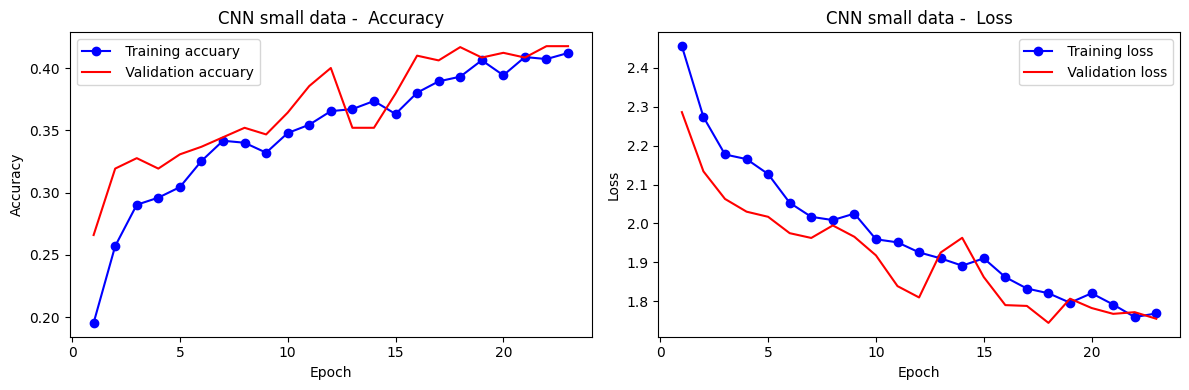

In [ ]:
base_model_full = cnn_model()
base_model_full.summary()

base_model_full.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)

base_model_full_history = base_model_full.fit(
    full_train_data,
    validation_data = full_val_data,
    callbacks = [early_stop],
    epochs = 50,
    verbose =1
)

plot_train_hist(base_model_full_history, title_prefix="CNN full data - ")

2026-01-10 19:09:55.604191: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:09:55.604272: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB



Cnn - full dataset - Classification Report

              precision    recall  f1-score   support

      Corals     0.2781    0.6912    0.3966        68
       Crabs     0.5841    0.8684    0.6984        76
     Dolphin     0.3641    0.6569    0.4685       102
         Eel     0.2923    0.2088    0.2436        91
  Jelly Fish     0.6507    0.7090    0.6786       134
     Lobster     0.4262    0.3662    0.3939        71
 Nudibranchs     0.3770    0.3651    0.3710        63
     Octopus     0.2391    0.1236    0.1630        89
     Puffers     0.1739    0.0964    0.1240        83
    Sea Rays     0.1509    0.0952    0.1168        84
    Seahorse     0.3500    0.3836    0.3660        73
        Seal     0.3469    0.3208    0.3333        53
      Sharks     0.3924    0.3298    0.3584        94
       Squid     0.6250    0.1220    0.2041        82
    Starfish     0.4062    0.5493    0.4671        71
       Whale     0.3509    0.2299    0.2778        87

    accuracy                       

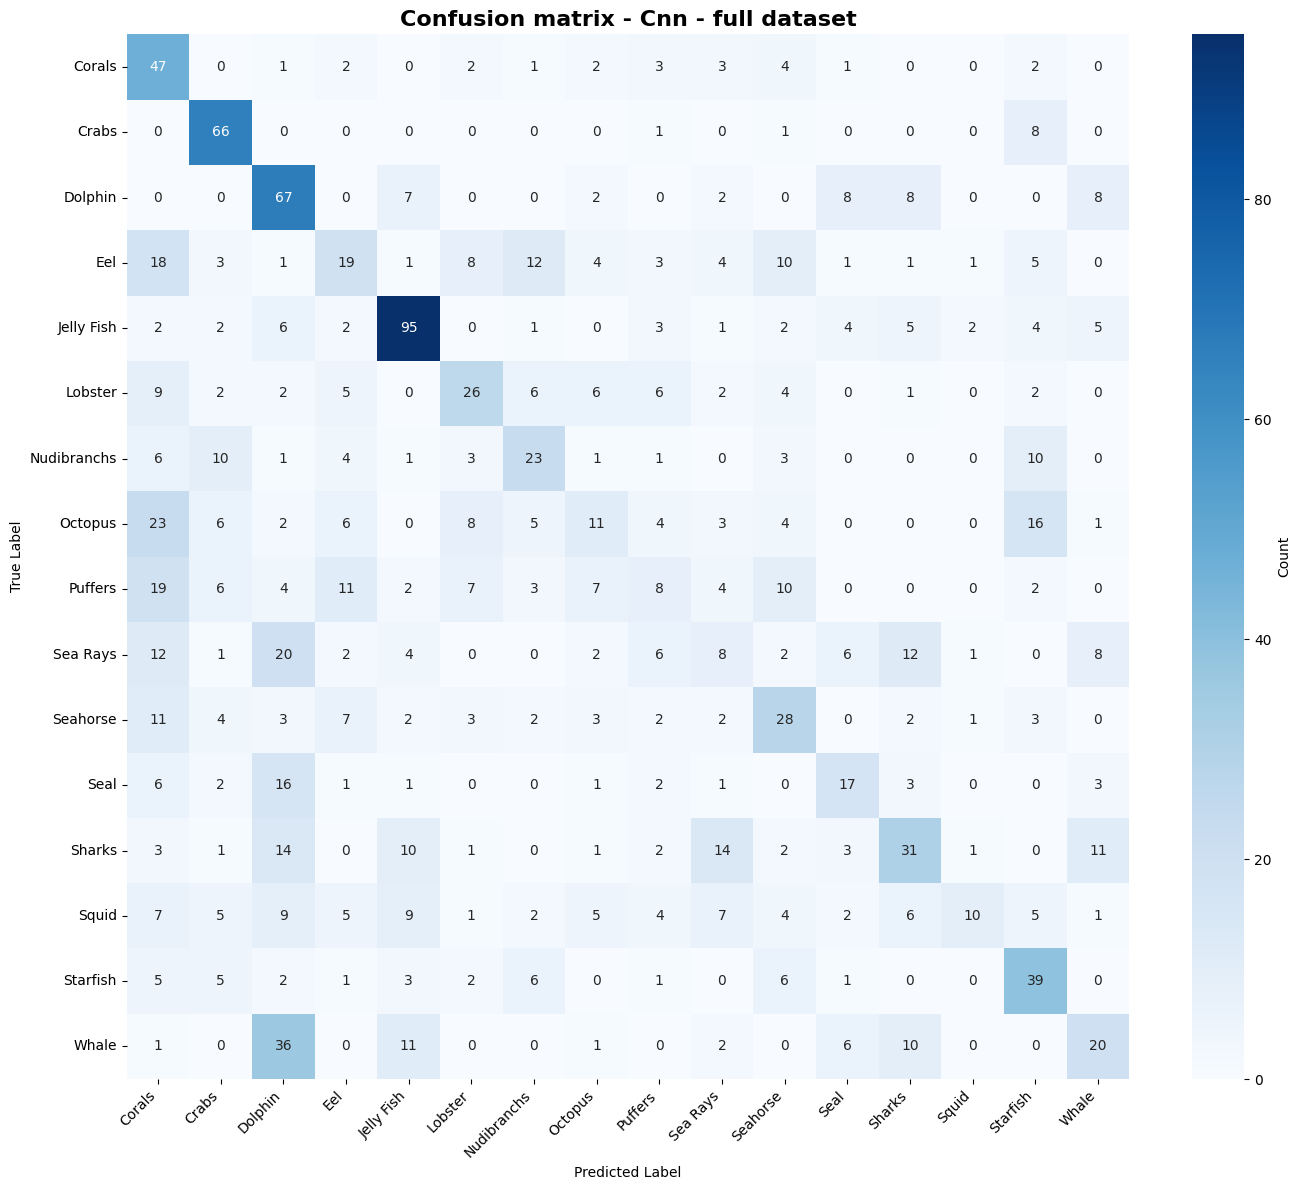


Cnn - full dataset - Metrics Table
      Class  Precision  Recall  F1-score  Support
     Corals     0.2781  0.6912    0.3966       68
      Crabs     0.5841  0.8684    0.6984       76
    Dolphin     0.3641  0.6569    0.4685      102
        Eel     0.2923  0.2088    0.2436       91
 Jelly Fish     0.6507  0.7090    0.6786      134
    Lobster     0.4262  0.3662    0.3939       71
Nudibranchs     0.3770  0.3651    0.3710       63
    Octopus     0.2391  0.1236    0.1630       89
    Puffers     0.1739  0.0964    0.1240       83
   Sea Rays     0.1509  0.0952    0.1168       84
   Seahorse     0.3500  0.3836    0.3660       73
       Seal     0.3469  0.3208    0.3333       53
     Sharks     0.3924  0.3298    0.3584       94
      Squid     0.6250  0.1220    0.2041       82
   Starfish     0.4062  0.5493    0.4671       71
      Whale     0.3509  0.2299    0.2778       87

Cnn - full dataset - Overall Metrics
            Metric  Score
          Accuracy 0.3899
Weighted Precision 0.384

In [ ]:
summary_cnn_full = eval_test(
    base_model_full, full_test_data, class_names, name="Cnn - full dataset")

- The best epochs is 18 but accuary is still too poor at 38%. This show improvement compared to the other one. 

- Confusion matrics is still poor but got better due to more data

- But will pretrained models perform better than cnn trained from scratch?

## MobileNetV2 : model creation

In [91]:
IMG_SHAPE = IMG_SIZE + (3,)

base_mobile = tf.keras.applications.MobileNetV2(input_shape = IMG_SHAPE,
                                                include_top = False,
                                                weights = "imagenet")

base_mobile.trainable = False # freeze pretrained weight

preprocess_mobile = tf.keras.applications.mobilenet_v2.preprocess_input

input_m = keras.Input(shape = IMG_SHAPE, name="input_image")
x_m = data_augu(input_m)
x_m = preprocess_mobile(x_m)
x_m = base_mobile(x_m, training = False)
x_m = layers.GlobalAveragePooling2D()(x_m)
x_m = layers.Dropout(0.3)(x_m)
outputs_m = layers.Dense(numclass, activation = "softmax", name="predictions")(x_m)

model_mobile = keras.Model(input_m, outputs_m, name="mobilenetv2_transfer")

model_mobile.summary()


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 16)             │        20,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,278,480 (8.69 MB)

 Trainable params: 20,496 (80.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### Training on smallset mobilenet

Epoch 1/30


2026-01-10 19:10:04.244354: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:10:04.244506: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB
2026-01-10 19:10:04.835625: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-10 19:10:04.840635: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-10 19:10:04.840692: W tensorflow/core/kernels/data/prefetch_autotuner.cc:5

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1247 - loss: 2.8655

2026-01-10 19:10:07.134815: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.2000 - loss: 2.6033 - val_accuracy: 0.4781 - val_loss: 1.8468
Epoch 2/30


...

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.7797 - loss: 0.7384 - val_accuracy: 0.7719 - val_loss: 0.7405
Epoch 19/30


2026-01-10 19:10:59.586062: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:10:59.586111: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


 3/20 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.7760 - loss: 0.7832

2026-01-10 19:11:00.248675: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-10 19:11:00.248729: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.7609 - loss: 0.7724 - val_accuracy: 0.7812 - val_loss: 0.7541
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 14.


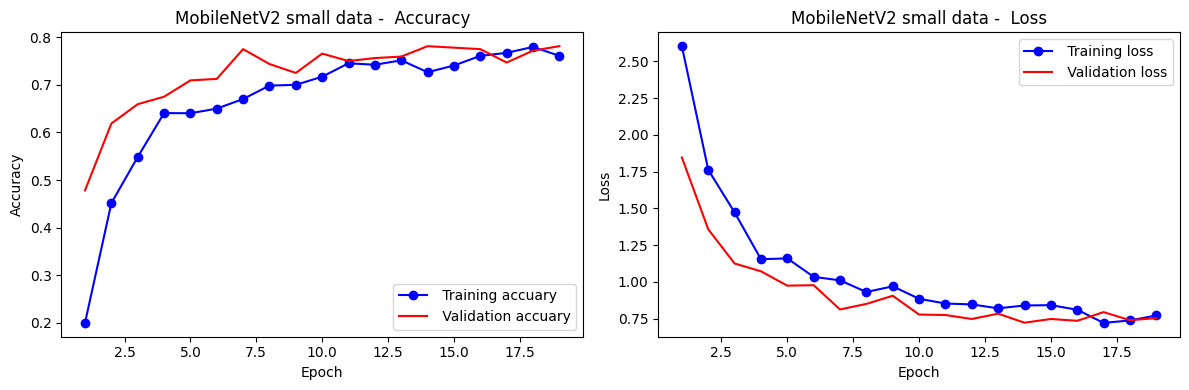

In [92]:
model_mobile.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)


#early_stop = keras.callbacks.EarlyStopping(monitor = "val_loss",
                                           #patience = 5, verbose =1, restore_best = True)

model_mobile_history_s = model_mobile.fit(
    small_train_data,
    validation_data = small_val_data,
    callbacks = [early_stop],
    epochs = 30,
    verbose =1
)

plot_train_hist(model_mobile_history_s, title_prefix="MobileNetV2 small data - ")

2026-01-10 19:11:02.666636: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:11:02.666704: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB



Mobile - small dataset - Classification Report

              precision    recall  f1-score   support

      Corals     0.5833    0.8448    0.6901        58
       Crabs     0.9610    0.9867    0.9737        75
     Dolphin     0.7890    0.8350    0.8113       103
         Eel     0.7241    0.7412    0.7326        85
  Jelly Fish     0.9449    0.8955    0.9195       134
     Lobster     0.8382    0.7703    0.8028        74
 Nudibranchs     0.8980    0.6984    0.7857        63
     Octopus     0.7429    0.5591    0.6380        93
     Puffers     0.7684    0.8391    0.8022        87
    Sea Rays     0.7179    0.6747    0.6957        83
    Seahorse     0.6747    0.7887    0.7273        71
        Seal     0.7812    0.8929    0.8333        56
      Sharks     0.6697    0.7300    0.6986       100
       Squid     0.7910    0.6625    0.7211        80
    Starfish     0.8791    1.0000    0.9357        80
       Whale     0.7778    0.6203    0.6901        79

    accuracy                   

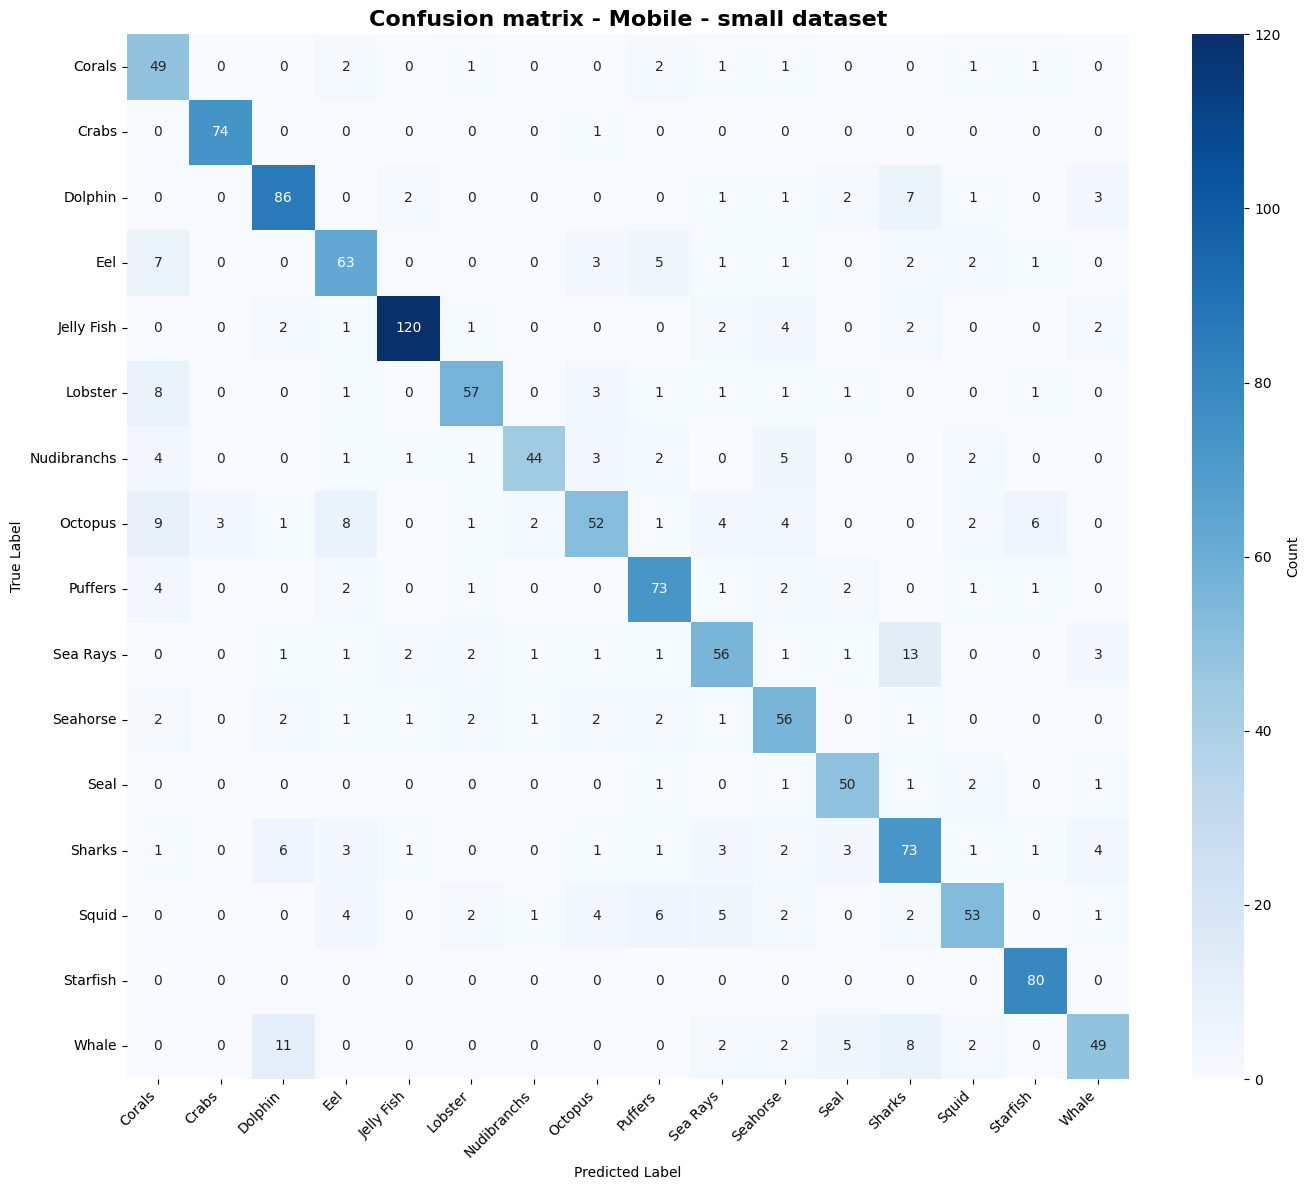


Mobile - small dataset - Metrics Table
      Class  Precision  Recall  F1-score  Support
     Corals     0.5833  0.8448    0.6901       58
      Crabs     0.9610  0.9867    0.9737       75
    Dolphin     0.7890  0.8350    0.8113      103
        Eel     0.7241  0.7412    0.7326       85
 Jelly Fish     0.9449  0.8955    0.9195      134
    Lobster     0.8382  0.7703    0.8028       74
Nudibranchs     0.8980  0.6984    0.7857       63
    Octopus     0.7429  0.5591    0.6380       93
    Puffers     0.7684  0.8391    0.8022       87
   Sea Rays     0.7179  0.6747    0.6957       83
   Seahorse     0.6747  0.7887    0.7273       71
       Seal     0.7812  0.8929    0.8333       56
     Sharks     0.6697  0.7300    0.6986      100
      Squid     0.7910  0.6625    0.7211       80
   Starfish     0.8791  1.0000    0.9357       80
      Whale     0.7778  0.6203    0.6901       79

Mobile - small dataset - Overall Metrics
            Metric  Score
          Accuracy 0.7835
Weighted Precisi

In [ ]:
summary_mobile_small = eval_test(
    model_mobile, full_test_data, class_names, name='Mobile - small dataset')

- Pretrained model shows massive improvement compared to cnn model

- Crabs and starfish was one of the best it got

- Best epochs was at 14 and the accuarcy is 78% 

#### Training on Full Dataset

Epoch 1/50


2026-01-10 19:11:10.333139: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:11:10.333197: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


  3/193 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.7240 - loss: 0.9167

2026-01-10 19:11:10.925711: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7390 - loss: 0.8138

...

193/193 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.8239 - loss: 0.5322 - val_accuracy: 0.7995 - val_loss: 0.6664
Epoch 15/50


2026-01-10 19:14:34.379132: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:14:34.379245: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


  3/193 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.7951 - loss: 0.5896

2026-01-10 19:14:35.076361: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


193/193 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.8221 - loss: 0.5271 - val_accuracy: 0.7881 - val_loss: 0.6909
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.


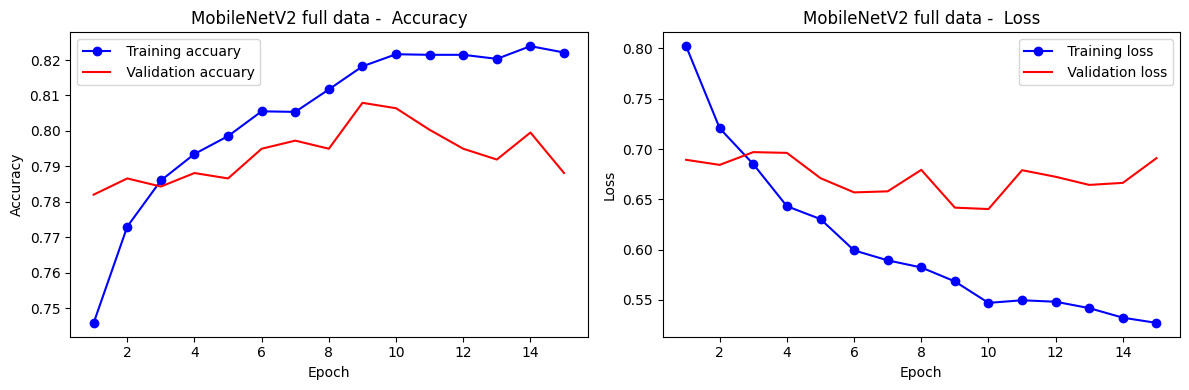

In [94]:
model_mobile_history_l = model_mobile.fit(
    full_train_data,
    validation_data = full_val_data,
    callbacks = [early_stop],
    epochs = 50,
    verbose =1
)

plot_train_hist(model_mobile_history_l, title_prefix="MobileNetV2 full data - ")

2026-01-10 19:14:49.505066: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:14:49.505143: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB



MobileNetV2 Full dataset - Classification Report

              precision    recall  f1-score   support

      Corals     0.7089    0.9180    0.8000        61
       Crabs     0.9868    0.9868    0.9868        76
     Dolphin     0.8218    0.8218    0.8218       101
         Eel     0.8415    0.7753    0.8070        89
  Jelly Fish     0.9524    0.9302    0.9412       129
     Lobster     0.8333    0.7927    0.8125        82
 Nudibranchs     0.7619    0.8136    0.7869        59
     Octopus     0.6854    0.6778    0.6816        90
     Puffers     0.7500    0.8889    0.8136        81
    Sea Rays     0.6630    0.7439    0.7011        82
    Seahorse     0.7973    0.8429    0.8194        70
        Seal     0.9111    0.7593    0.8283        54
      Sharks     0.8553    0.6132    0.7143       106
       Squid     0.8636    0.6628    0.7500        86
    Starfish     0.9867    0.9867    0.9867        75
       Whale     0.6214    0.8000    0.6995        80

    accuracy                 

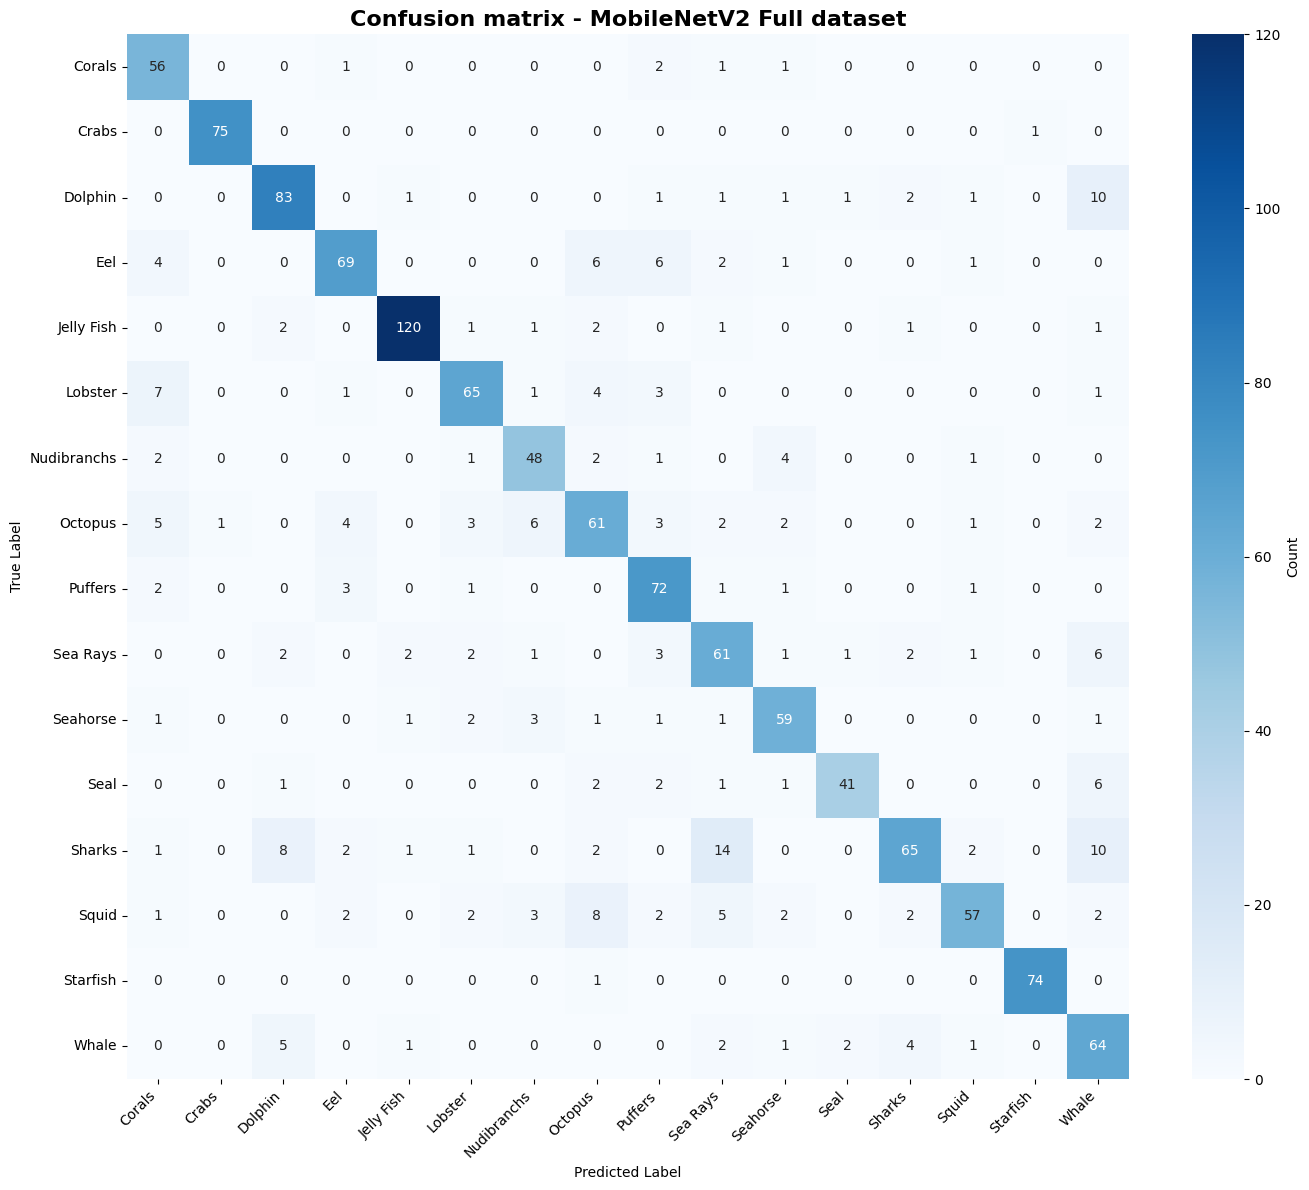


MobileNetV2 Full dataset - Metrics Table
      Class  Precision  Recall  F1-score  Support
     Corals     0.7089  0.9180    0.8000       61
      Crabs     0.9868  0.9868    0.9868       76
    Dolphin     0.8218  0.8218    0.8218      101
        Eel     0.8415  0.7753    0.8070       89
 Jelly Fish     0.9524  0.9302    0.9412      129
    Lobster     0.8333  0.7927    0.8125       82
Nudibranchs     0.7619  0.8136    0.7869       59
    Octopus     0.6854  0.6778    0.6816       90
    Puffers     0.7500  0.8889    0.8136       81
   Sea Rays     0.6630  0.7439    0.7011       82
   Seahorse     0.7973  0.8429    0.8194       70
       Seal     0.9111  0.7593    0.8283       54
     Sharks     0.8553  0.6132    0.7143      106
      Squid     0.8636  0.6628    0.7500       86
   Starfish     0.9867  0.9867    0.9867       75
      Whale     0.6214  0.8000    0.6995       80

MobileNetV2 Full dataset - Overall Metrics
            Metric  Score
          Accuracy 0.8100
Weighted Pre

In [ ]:
## Evaluate the data
summary_mobile_full = eval_test(
    model_mobile, full_test_data, class_names, name="MobileNetV2 Full dataset")

- It stopped early 10 epochs showing overfitting. This is still due to the forzon layer

- Accuracy improve to 81% compared to the small dataset crrabs and starfish still the highest score confusion matrix getting better

Epoch 1/50


/home/bello_the_great/Downloads/ml_cw/bello/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")
2026-01-10 19:14:59.382543: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:14:59.382613: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


  3/193 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.8177 - loss: 0.6828

2026-01-10 19:15:00.281466: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8350 - loss: 0.5198

...

193/193 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.8251 - loss: 0.5307 - val_accuracy: 0.8064 - val_loss: 0.6322
Epoch 13/50


2026-01-10 19:18:08.384550: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:18:08.384613: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8238 - loss: 0.5359

2026-01-10 19:18:22.640339: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:18:22.640908: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


193/193 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.8265 - loss: 0.5312 - val_accuracy: 0.8072 - val_loss: 0.6349
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.


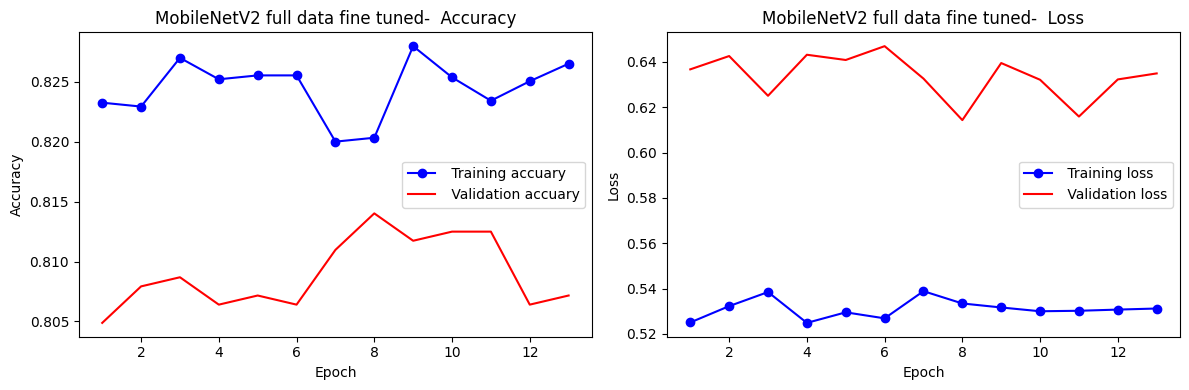

In [96]:
## Fine Tuning the dataset

# Unfreeze some layers

model_mobile.trainable = True

finetune_mb = 100 # freeze the first 100 layer and the rest unforzen
for layers in model_mobile.layers[:finetune_mb]:
    layers.trainable = False


model_mobile.compile(
    optimizer = keras.optimizers.Adam(1e-4),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)

model_mobile_history_l = model_mobile.fit(
    full_train_data,
    validation_data = full_val_data,
    callbacks = [early_stop],
    epochs = 50,
    verbose =1
)

plot_train_hist(model_mobile_history_l, title_prefix="MobileNetV2 full data fine tuned- ")

2026-01-10 19:18:23.801953: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:18:23.802058: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB
2026-01-10 19:18:32.017929: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



MobileNetV2 Full dataset fine tuned  - Classification Report

              precision    recall  f1-score   support

      Corals     0.7037    0.9194    0.7972        62
       Crabs     0.9863    0.9863    0.9863        73
     Dolphin     0.8302    0.8381    0.8341       105
         Eel     0.8072    0.7363    0.7701        91
  Jelly Fish     0.9621    0.9338    0.9478       136
     Lobster     0.8028    0.7808    0.7917        73
 Nudibranchs     0.7903    0.8305    0.8099        59
     Octopus     0.7126    0.6739    0.6927        92
     Puffers     0.7426    0.8824    0.8065        85
    Sea Rays     0.6596    0.7654    0.7086        81
    Seahorse     0.8235    0.8235    0.8235        68
        Seal     0.9400    0.7833    0.8545        60
      Sharks     0.8451    0.6122    0.7101        98
       Squid     0.8788    0.6905    0.7733        84
    Starfish     0.9863    0.9863    0.9863        73
       Whale     0.6311    0.8025    0.7065        81

    accuracy     

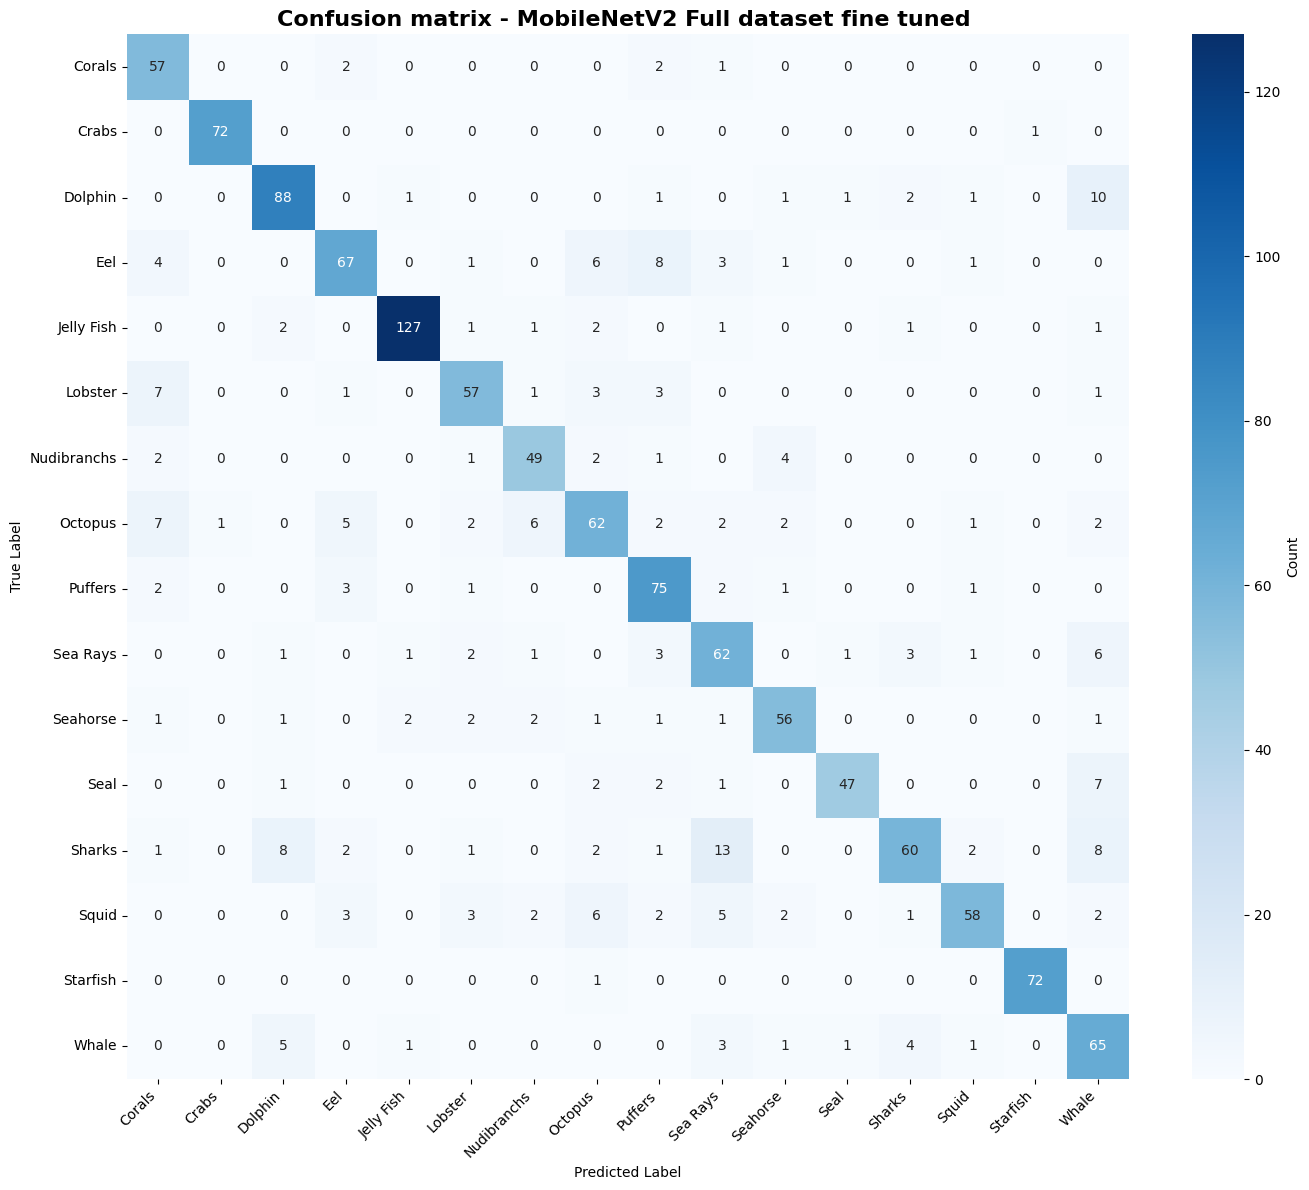


MobileNetV2 Full dataset fine tuned  - Metrics Table
      Class  Precision  Recall  F1-score  Support
     Corals     0.7037  0.9194    0.7972       62
      Crabs     0.9863  0.9863    0.9863       73
    Dolphin     0.8302  0.8381    0.8341      105
        Eel     0.8072  0.7363    0.7701       91
 Jelly Fish     0.9621  0.9338    0.9478      136
    Lobster     0.8028  0.7808    0.7917       73
Nudibranchs     0.7903  0.8305    0.8099       59
    Octopus     0.7126  0.6739    0.6927       92
    Puffers     0.7426  0.8824    0.8065       85
   Sea Rays     0.6596  0.7654    0.7086       81
   Seahorse     0.8235  0.8235    0.8235       68
       Seal     0.9400  0.7833    0.8545       60
     Sharks     0.8451  0.6122    0.7101       98
      Squid     0.8788  0.6905    0.7733       84
   Starfish     0.9863  0.9863    0.9863       73
      Whale     0.6311  0.8025    0.7065       81

MobileNetV2 Full dataset fine tuned  - Overall Metrics
            Metric  Score
          Accu

In [ ]:
# fine tuned evaluate
summary_mobile_ft = eval_test(
    model_mobile, full_test_data, class_names, name="MobileNetV2 Full dataset fine tuned ")

- The unfrozon layer is got the same score at 81 but epochs stops at 8.

- Shows fewer training compare to the full dataset

- There has been a slight improvement but overall still the same

#### Resnet : model creation

In [98]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers
from tensorflow.keras.applications.resnet50 import preprocess_input


preprocess_input_res = preprocess_input

rest_base = ResNet50(input_shape = IMG_SHAPE,
                    include_top = False,
                    weights = "imagenet")

rest_base.trainable = False      # freeze layers

input = keras.Input(shape = IMG_SHAPE, name="input_image")
y_r = data_augu(input)
y_r = preprocess_input_res(y_r)
y_r =rest_base(y_r, training = False)
y_r = tf.keras.layers.GlobalAveragePooling2D()(y_r)
y_r = tf.keras.layers.Dropout(0.3)(y_r)
output_r = layers.Dense(numclass,
                        activation = "softmax",
                        name="predictions")(y_r)
res_model = keras.Model(input, output_r, name="resnet50_transfer")
res_model.summary()

Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 2048)      │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 16)        │     32,784 │ dropout_19[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,620,496 (90.11 MB)

 Trainable params: 32,784 (128.06 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/30


2026-01-10 19:18:41.629073: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:18:41.629145: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB
2026-01-10 19:18:42.423027: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-10 19:18:42.431462: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-10 19:18:42.431598: W tensorflow/core/kernels/data/prefetch_autotuner.cc:5

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.1438 - loss: 3.0498

2026-01-10 19:18:48.029612: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 310ms/step - accuracy: 0.2375 - loss: 2.6414 - val_accuracy: 0.4187 - val_loss: 1.7695
Epoch 2/30


...

 1/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.6875 - loss: 0.8825

2026-01-10 19:19:08.501021: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6587 - loss: 0.9859

2026-01-10 19:19:11.179080: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 0.6578 - loss: 1.0353 - val_accuracy: 0.7375 - val_loss: 0.9083
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


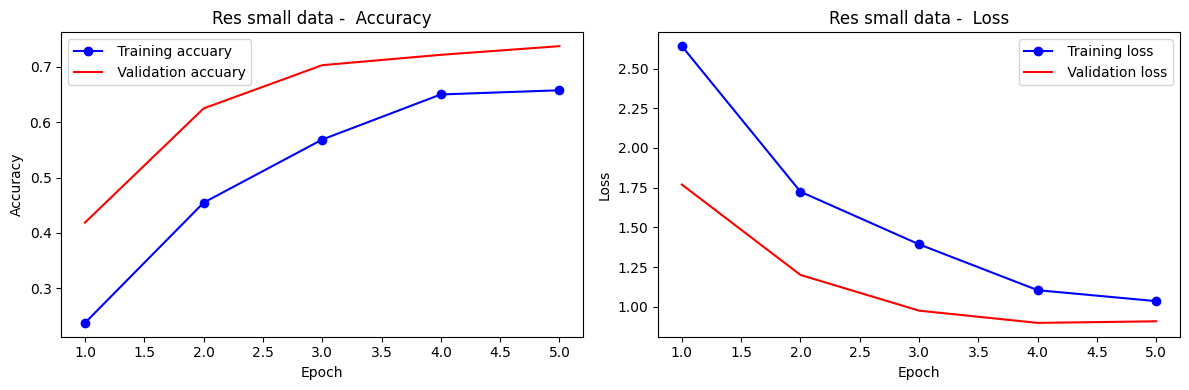

In [99]:
# Training use small dataset
res_model.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)

res_history_s = res_model.fit(
    small_train_data,
    validation_data = small_val_data,
    callbacks = [early_stop],
    epochs = 30,
    verbose =1
)

plot_train_hist(res_history_s, title_prefix="Res small data - ")

2026-01-10 19:19:13.468670: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:19:13.468772: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB
2026-01-10 19:19:13.476352: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Resnet small - Classification Report

              precision    recall  f1-score   support

      Corals     0.4615    0.1967    0.2759        61
       Crabs     0.8023    0.9452    0.8679        73
     Dolphin     0.2230    0.9048    0.3578       105
         Eel     0.3385    0.5000    0.4037        88
  Jelly Fish     0.6994    0.8288    0.7586       146
     Lobster     0.8421    0.4638    0.5981        69
 Nudibranchs     0.3846    0.3509    0.3670        57
     Octopus     0.2593    0.1591    0.1972        88
     Puffers     0.2891    0.4253    0.3442        87
    Sea Rays     0.3636    0.0988    0.1553        81
    Seahorse     0.5556    0.2532    0.3478        79
        Seal     0.5000    0.0357    0.0667        56
      Sharks     0.6667    0.0842    0.1495        95
       Squid     0.3462    0.1125    0.1698        80
    Starfish     0.7681    0.7067    0.7361        75
       Whale     0.6410    0.3086    0.4167        81

    accuracy                         0.43

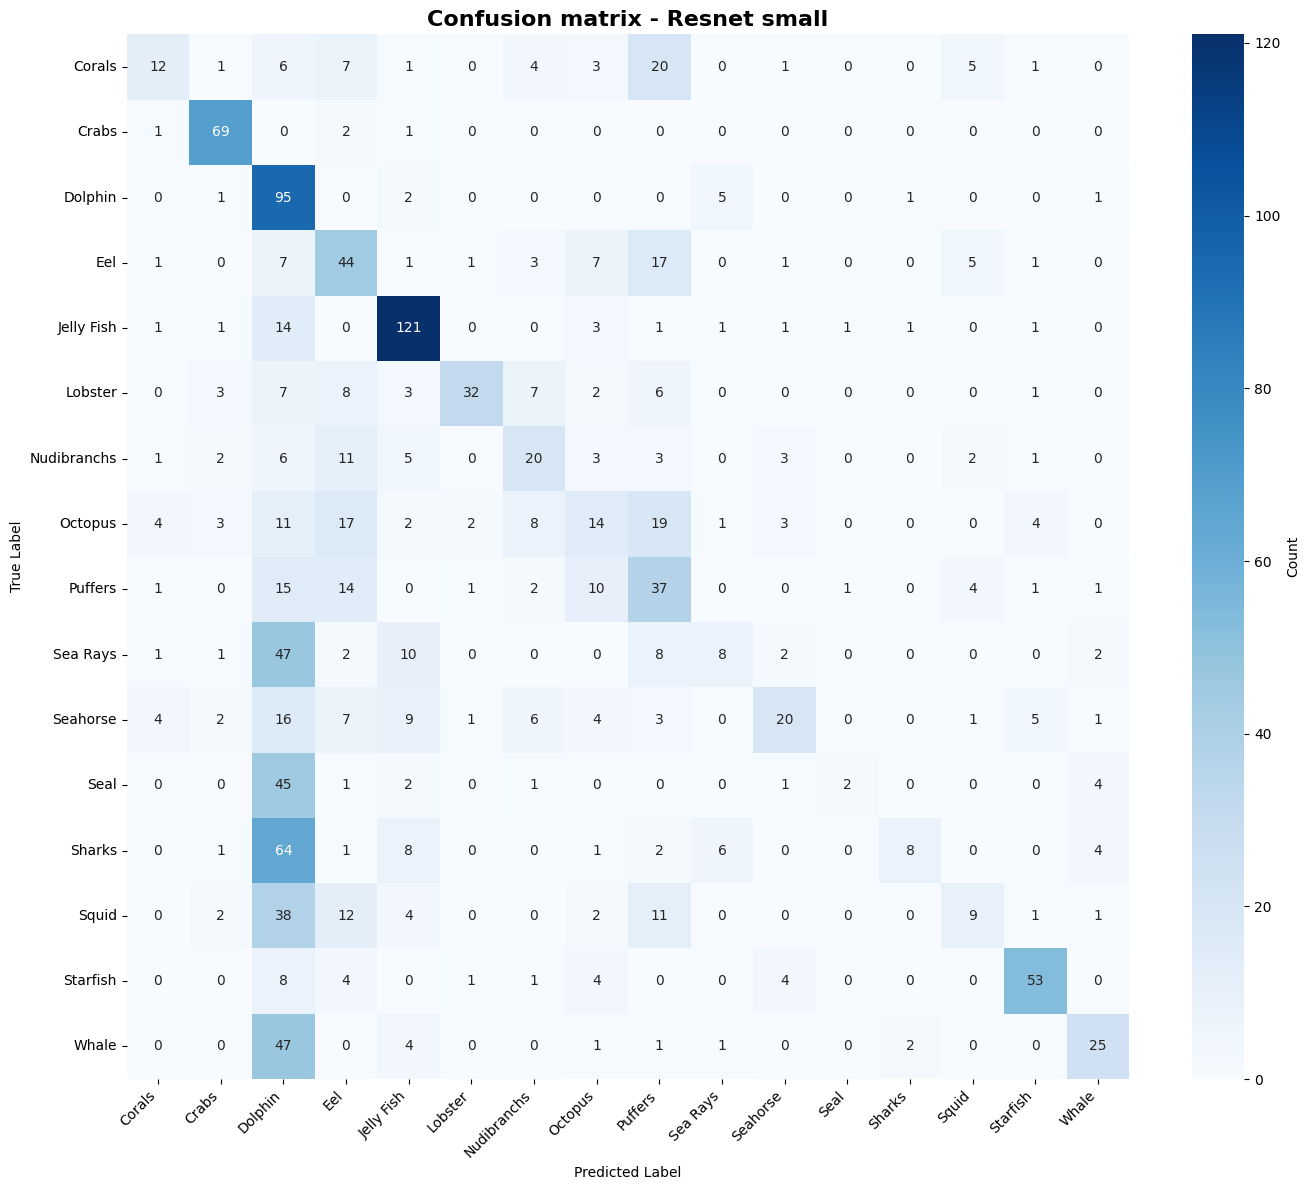


Resnet small - Metrics Table
      Class  Precision  Recall  F1-score  Support
     Corals     0.4615  0.1967    0.2759       61
      Crabs     0.8023  0.9452    0.8679       73
    Dolphin     0.2230  0.9048    0.3578      105
        Eel     0.3385  0.5000    0.4037       88
 Jelly Fish     0.6994  0.8288    0.7586      146
    Lobster     0.8421  0.4638    0.5981       69
Nudibranchs     0.3846  0.3509    0.3670       57
    Octopus     0.2593  0.1591    0.1972       88
    Puffers     0.2891  0.4253    0.3442       87
   Sea Rays     0.3636  0.0988    0.1553       81
   Seahorse     0.5556  0.2532    0.3478       79
       Seal     0.5000  0.0357    0.0667       56
     Sharks     0.6667  0.0842    0.1495       95
      Squid     0.3462  0.1125    0.1698       80
   Starfish     0.7681  0.7067    0.7361       75
      Whale     0.6410  0.3086    0.4167       81

Resnet small - Overall Metrics
            Metric  Score
          Accuracy 0.4307
Weighted Precision 0.5087
   Weighte

In [ ]:

# Evalaute for resnet
summary_res_small = eval_test(
    res_model, full_test_data, class_names, name='Resnet small')

- Best epochs was but accuarcy is 43%

- This is due to small data

Epoch 1/50


2026-01-10 19:19:27.821805: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:19:27.821855: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


  1/193 ━━━━━━━━━━━━━━━━━━━━ 6:08 2s/step - accuracy: 0.4062 - loss: 1.9445

2026-01-10 19:19:28.625688: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5810 - loss: 1.3531

...

  1/193 ━━━━━━━━━━━━━━━━━━━━ 6:52 2s/step - accuracy: 0.9062 - loss: 0.2740

2026-01-10 19:23:43.682542: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-10 19:23:43.689810: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8494 - loss: 0.4482

2026-01-10 19:24:11.941189: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:24:11.941260: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


193/193 ━━━━━━━━━━━━━━━━━━━━ 32s 156ms/step - accuracy: 0.8462 - loss: 0.4708 - val_accuracy: 0.8110 - val_loss: 0.6128
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.


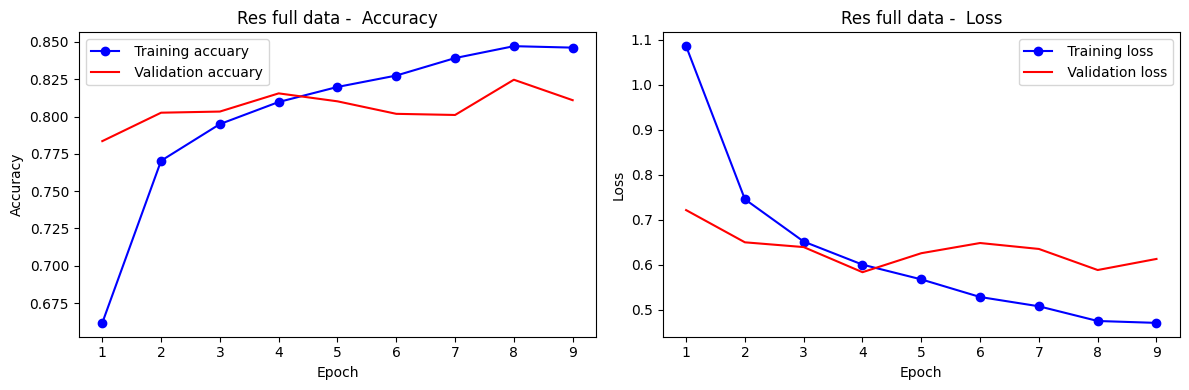

In [101]:
# Training the full dataset
res_history = res_model.fit(
    full_train_data,
    validation_data = full_val_data,
    callbacks = [early_stop],
    epochs = 50,
    verbose =1
)

plot_train_hist(res_history, title_prefix = "Res full data - ")

2026-01-10 19:24:14.701044: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:24:14.702149: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB



Resnet Full dataset - Classification Report

              precision    recall  f1-score   support

      Corals     0.7436    0.9062    0.8169        64
       Crabs     0.9744    0.9744    0.9744        78
     Dolphin     0.7851    0.9223    0.8482       103
         Eel     0.7273    0.7442    0.7356        86
  Jelly Fish     0.9528    0.9098    0.9308       133
     Lobster     0.7595    0.8571    0.8054        70
 Nudibranchs     0.8214    0.7797    0.8000        59
     Octopus     0.7436    0.6517    0.6946        89
     Puffers     0.8235    0.7089    0.7619        79
    Sea Rays     0.7033    0.8000    0.7485        80
    Seahorse     0.8158    0.8267    0.8212        75
        Seal     0.8889    0.8276    0.8571        58
      Sharks     0.7625    0.6040    0.6740       101
       Squid     0.8831    0.7473    0.8095        91
    Starfish     0.9146    0.9868    0.9494        76
       Whale     0.6818    0.7595    0.7186        79

    accuracy                      

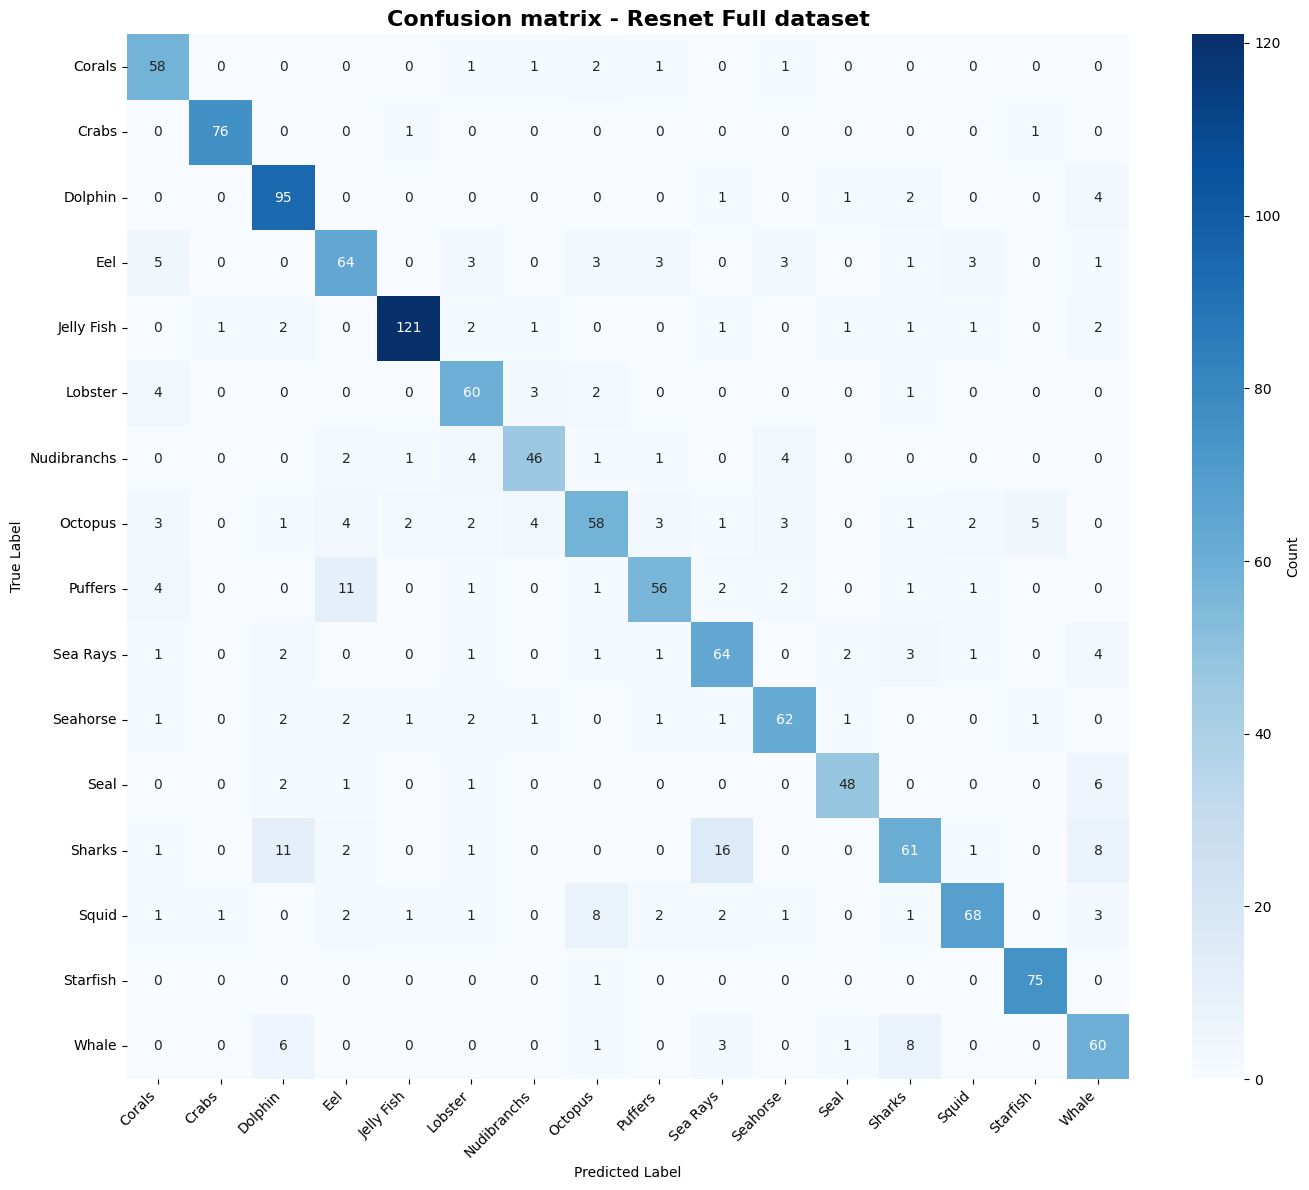


Resnet Full dataset - Metrics Table
      Class  Precision  Recall  F1-score  Support
     Corals     0.7436  0.9062    0.8169       64
      Crabs     0.9744  0.9744    0.9744       78
    Dolphin     0.7851  0.9223    0.8482      103
        Eel     0.7273  0.7442    0.7356       86
 Jelly Fish     0.9528  0.9098    0.9308      133
    Lobster     0.7595  0.8571    0.8054       70
Nudibranchs     0.8214  0.7797    0.8000       59
    Octopus     0.7436  0.6517    0.6946       89
    Puffers     0.8235  0.7089    0.7619       79
   Sea Rays     0.7033  0.8000    0.7485       80
   Seahorse     0.8158  0.8267    0.8212       75
       Seal     0.8889  0.8276    0.8571       58
     Sharks     0.7625  0.6040    0.6740      101
      Squid     0.8831  0.7473    0.8095       91
   Starfish     0.9146  0.9868    0.9494       76
      Whale     0.6818  0.7595    0.7186       79

Resnet Full dataset - Overall Metrics
            Metric  Score
          Accuracy 0.8115
Weighted Precision 0.8

In [ ]:
# Evalaute the data
summary_res_ft = eval_test(
    res_model, full_test_data, class_names, name='Resnet Full dataset')

- There has been improvement from 43 to 81 percent

- With frozon layer it got this 

- The best epochs was at 4 and due to the data got better not limited like the small dataset

Epoch 1/50


/home/bello_the_great/Downloads/ml_cw/bello/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")
2026-01-10 19:24:34.035499: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:24:34.035583: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


  1/193 ━━━━━━━━━━━━━━━━━━━━ 27:58 9s/step - accuracy: 0.8125 - loss: 0.5817

2026-01-10 19:24:35.099578: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8255 - loss: 0.5427

...

  1/193 ━━━━━━━━━━━━━━━━━━━━ 6:29 2s/step - accuracy: 0.7500 - loss: 0.7479

2026-01-10 19:26:45.145328: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8244 - loss: 0.5624

2026-01-10 19:27:14.385045: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:27:14.385121: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


193/193 ━━━━━━━━━━━━━━━━━━━━ 32s 156ms/step - accuracy: 0.8288 - loss: 0.5335 - val_accuracy: 0.8117 - val_loss: 0.5878
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


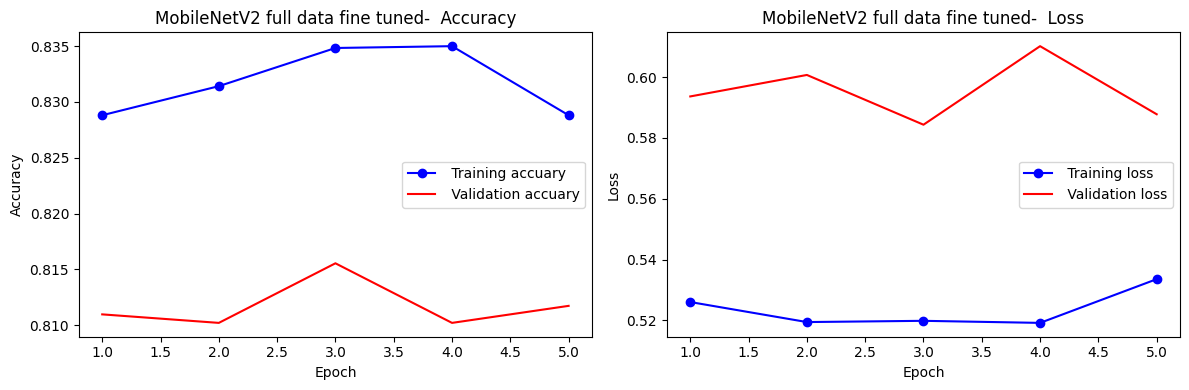

In [103]:
## Fine Tuning the dataset

# Unfreeze some layers

res_model.trainable = True

finetune_rn = 140 # freeze the first 140 layer and the rest unforzen
for layers in res_model.layers[:finetune_rn]:
    layers.trainable = False


res_model.compile(
    optimizer = keras.optimizers.Adam(1e-4),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)

res_history_ft = res_model.fit(
    full_train_data,
    validation_data = full_val_data,
    callbacks = [early_stop],
    epochs = 50,
    verbose =1
)

plot_train_hist(res_history_ft, title_prefix="MobileNetV2 full data fine tuned- ")

2026-01-10 19:27:16.090035: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:27:16.090257: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB



Resnet Full dataset fine tuned  - Classification Report

              precision    recall  f1-score   support

      Corals     0.7500    0.9265    0.8289        68
       Crabs     0.9868    0.9740    0.9804        77
     Dolphin     0.7686    0.9394    0.8455        99
         Eel     0.7363    0.7701    0.7528        87
  Jelly Fish     0.9583    0.9127    0.9350       126
     Lobster     0.7805    0.8649    0.8205        74
 Nudibranchs     0.8361    0.7969    0.8160        64
     Octopus     0.7625    0.6703    0.7135        91
     Puffers     0.8286    0.7073    0.7632        82
    Sea Rays     0.7356    0.8000    0.7665        80
    Seahorse     0.8060    0.7941    0.8000        68
        Seal     0.8909    0.8448    0.8673        58
      Sharks     0.8000    0.5941    0.6818       101
       Squid     0.8889    0.7805    0.8312        82
    Starfish     0.9286    0.9873    0.9571        79
       Whale     0.6979    0.7882    0.7403        85

    accuracy          

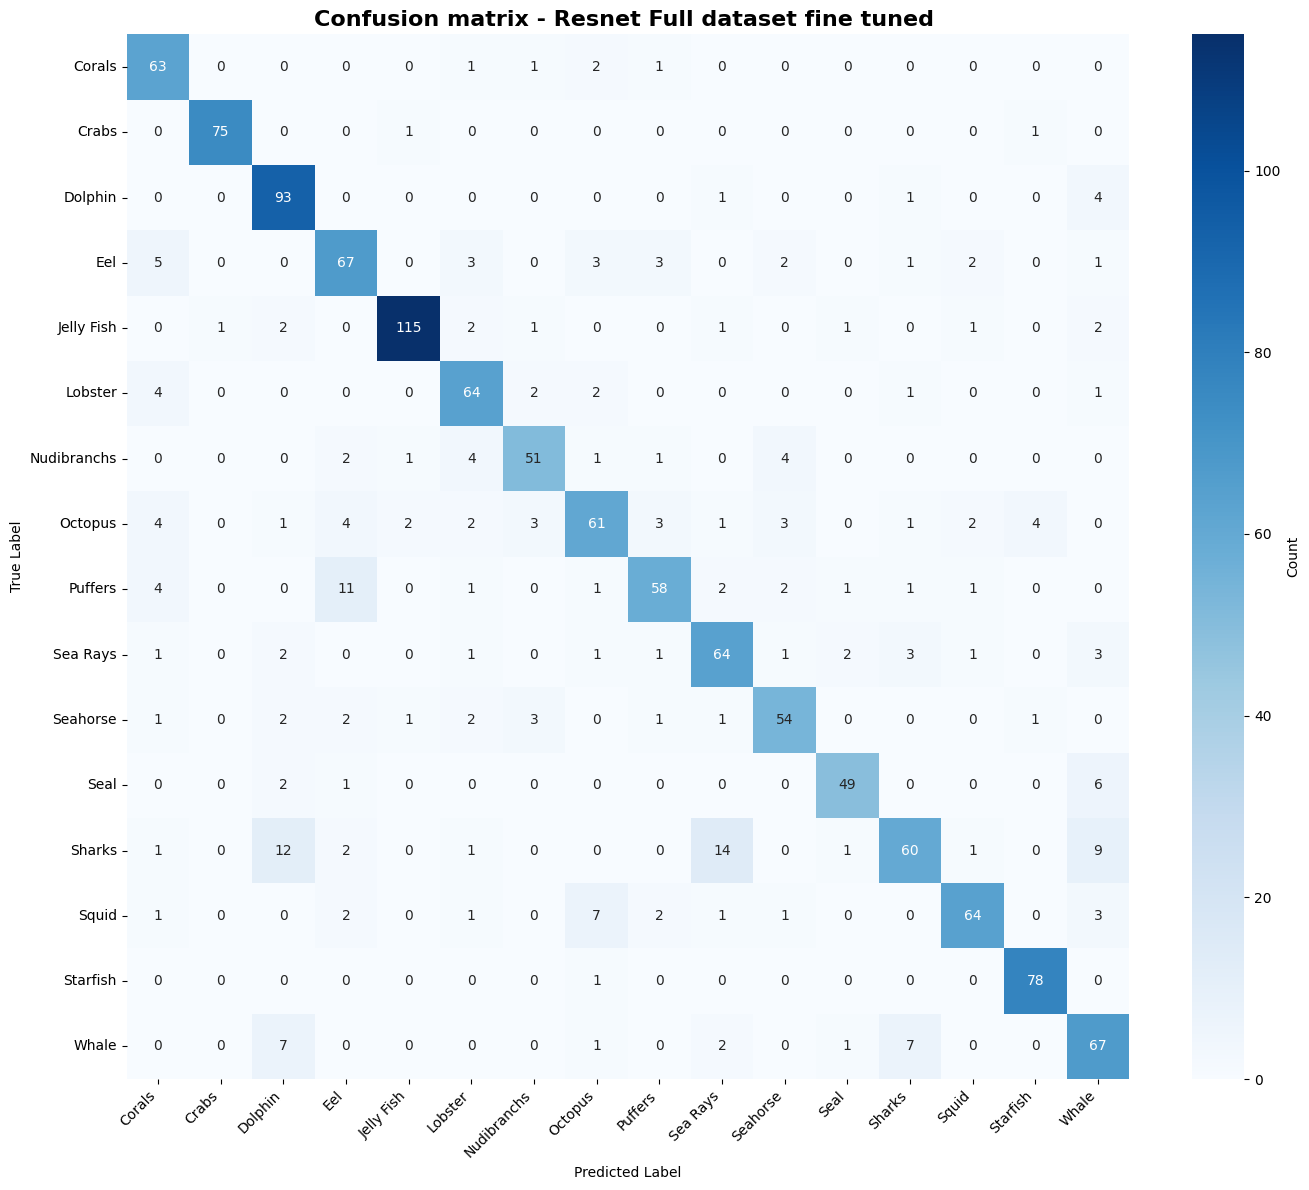


Resnet Full dataset fine tuned  - Metrics Table
      Class  Precision  Recall  F1-score  Support
     Corals     0.7500  0.9265    0.8289       68
      Crabs     0.9868  0.9740    0.9804       77
    Dolphin     0.7686  0.9394    0.8455       99
        Eel     0.7363  0.7701    0.7528       87
 Jelly Fish     0.9583  0.9127    0.9350      126
    Lobster     0.7805  0.8649    0.8205       74
Nudibranchs     0.8361  0.7969    0.8160       64
    Octopus     0.7625  0.6703    0.7135       91
    Puffers     0.8286  0.7073    0.7632       82
   Sea Rays     0.7356  0.8000    0.7665       80
   Seahorse     0.8060  0.7941    0.8000       68
       Seal     0.8909  0.8448    0.8673       58
     Sharks     0.8000  0.5941    0.6818      101
      Squid     0.8889  0.7805    0.8312       82
   Starfish     0.9286  0.9873    0.9571       79
      Whale     0.6979  0.7882    0.7403       85

Resnet Full dataset fine tuned  - Overall Metrics
            Metric  Score
          Accuracy 0.819

In [ ]:
#  Evalaute the data
summary_res_ft = eval_test(
    res_model, full_test_data, class_names, name='Resnet Full dataset fine tuned ')

- There was only been a slight difference with unfrozen layer but accuracy still remain the same.

- Epochs stops at 1 compare to full data which is 4

# EfficientNet V2

In [105]:
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as preprocess_efficient

eff = EfficientNetV2S(
    input_shape = IMG_SHAPE,
    include_top= False,
    weights="imagenet"
)

eff.trainable = False # freeze base

input_e = keras.Input(shape=IMG_SHAPE, name="input_image")
z_e = data_augu(input_e)
z_e = preprocess_efficient(z_e)
z_e = eff(z_e, training = False)
z_e = tf.keras.layers.GlobalAveragePooling2D()(z_e)
z_e = tf.keras.layers.Dropout(0.3)(z_e)
output_e = tf.keras.layers.Dense(numclass, activation = "softmax", name="prediction")(z_e)

eff_model = keras.Model(input_e, output_e, name = "efficentv2_transfer")
eff_model.summary()

Model: "efficentv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 16)             │        20,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,351,856 (77.64 MB)

 Trainable params: 20,496 (80.06 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

## Train small dataset

Epoch 1/30


2026-01-10 19:28:03.897742: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:28:03.898621: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB
2026-01-10 19:28:04.906615: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-10 19:28:04.917363: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-10 19:28:04.917447: W tensorflow/core/kernels/data/prefetch_autotuner.cc:5

20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 633ms/step - accuracy: 0.3641 - loss: 2.3481 - val_accuracy: 0.6906 - val_loss: 1.7311
Epoch 2/30


2026-01-10 19:28:18.762019: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:28:18.762109: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


 1/20 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5938 - loss: 1.7918

...

 1/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.6875 - loss: 1.1382

2026-01-10 19:28:33.438442: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-10 19:28:33.438822: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 247ms/step - accuracy: 0.7516 - loss: 0.9784 - val_accuracy: 0.7563 - val_loss: 0.8402
Epoch 5/30


2026-01-10 19:28:39.097758: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:28:39.097867: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 243ms/step - accuracy: 0.7718 - loss: 0.8719 - val_accuracy: 0.7500 - val_loss: 0.7901
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


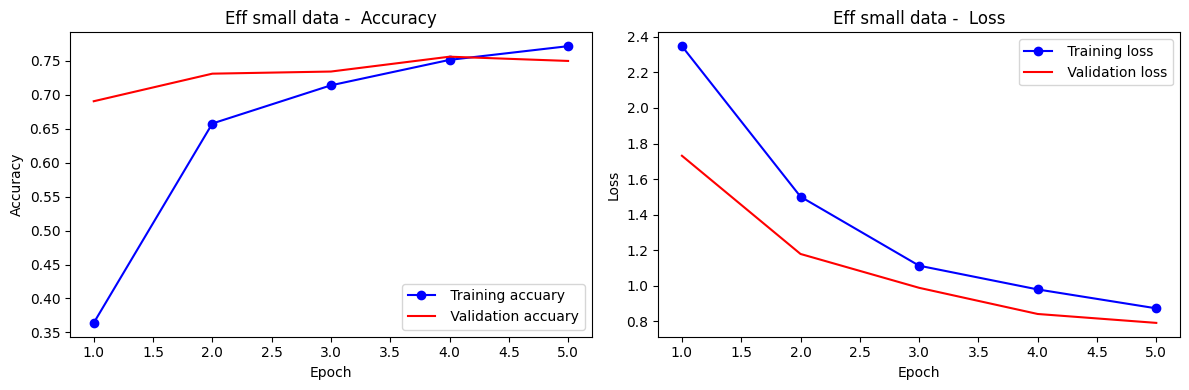

In [106]:
# Training use small dataset
eff_model.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)

eff_history_s = eff_model.fit(
    small_train_data,
    validation_data = small_val_data,
    callbacks = [early_stop],
    epochs = 30,
    verbose =1
)

plot_train_hist(eff_history_s, title_prefix="Eff small data - ")

2026-01-10 19:28:46.369488: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:28:46.369550: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB



Eff small - Classification Report

              precision    recall  f1-score   support

      Corals     0.3563    0.9500    0.5182        60
       Crabs     0.9846    0.8649    0.9209        74
     Dolphin     0.4203    0.8700    0.5668       100
         Eel     0.7128    0.7614    0.7363        88
  Jelly Fish     0.8414    0.9173    0.8777       133
     Lobster     0.7571    0.7067    0.7310        75
 Nudibranchs     0.8205    0.5517    0.6598        58
     Octopus     0.4839    0.1705    0.2521        88
     Puffers     0.8315    0.8409    0.8362        88
    Sea Rays     0.6078    0.7654    0.6776        81
    Seahorse     0.6000    0.2083    0.3093        72
        Seal     1.0000    0.4833    0.6517        60
      Sharks     0.8082    0.6020    0.6901        98
       Squid     0.6471    0.5366    0.5867        82
    Starfish     0.7917    0.9744    0.8736        78
       Whale     0.7500    0.2442    0.3684        86

    accuracy                         0.6639 

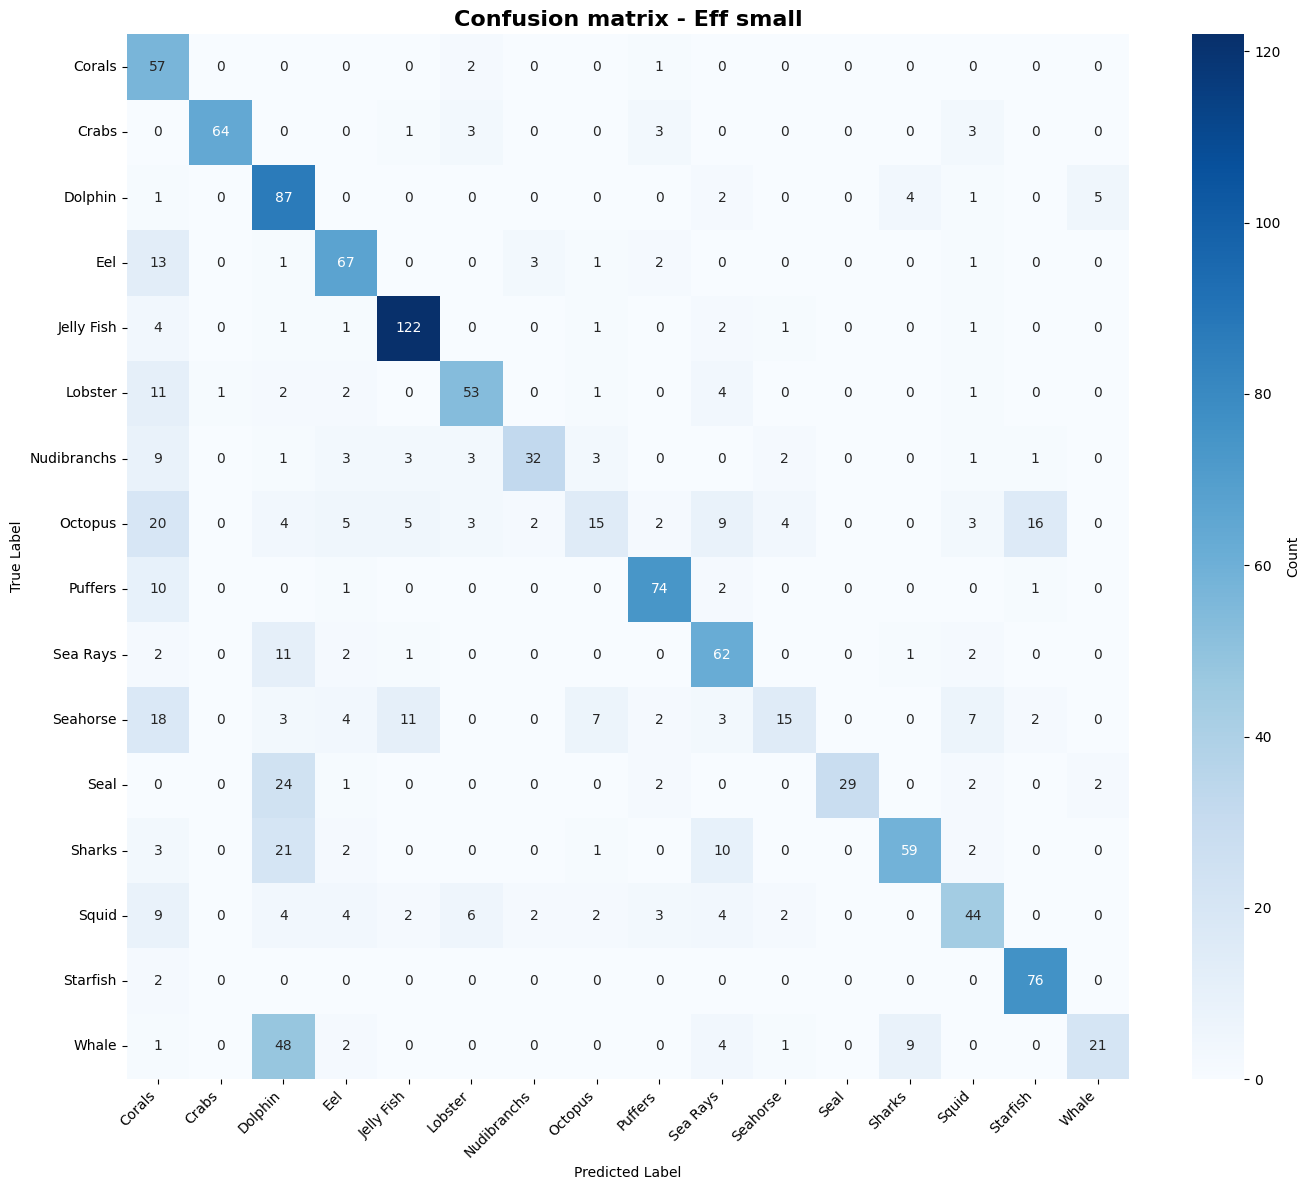


Eff small - Metrics Table
      Class  Precision  Recall  F1-score  Support
     Corals     0.3562  0.9500    0.5182       60
      Crabs     0.9846  0.8649    0.9209       74
    Dolphin     0.4203  0.8700    0.5668      100
        Eel     0.7128  0.7614    0.7363       88
 Jelly Fish     0.8414  0.9173    0.8777      133
    Lobster     0.7571  0.7067    0.7310       75
Nudibranchs     0.8205  0.5517    0.6598       58
    Octopus     0.4839  0.1705    0.2521       88
    Puffers     0.8315  0.8409    0.8362       88
   Sea Rays     0.6078  0.7654    0.6776       81
   Seahorse     0.6000  0.2083    0.3093       72
       Seal     1.0000  0.4833    0.6517       60
     Sharks     0.8082  0.6020    0.6901       98
      Squid     0.6471  0.5366    0.5867       82
   Starfish     0.7917  0.9744    0.8736       78
      Whale     0.7500  0.2442    0.3684       86

Eff small - Overall Metrics
            Metric  Score
          Accuracy 0.6639
Weighted Precision 0.7131
   Weighted Reca

In [ ]:
# Evaluate eff small
summary_eff = eval_test(
    eff_model, full_test_data, class_names, name='Eff small')

- Its the best in small data with accuracy if 66%

- Due to small data it achieve this and stops at epoch 1 

# Full dataset train

Epoch 1/50


2026-01-10 19:29:08.002641: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:29:08.002758: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.6976 - loss: 1.2091

2026-01-10 19:29:43.986779: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:29:43.986840: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


193/193 ━━━━━━━━━━━━━━━━━━━━ 39s 194ms/step - accuracy: 0.7356 - loss: 0.9621 - val_accuracy: 0.8034 - val_loss: 0.6481
Epoch 2/50


...

  1/193 ━━━━━━━━━━━━━━━━━━━━ 6:21 2s/step - accuracy: 0.9375 - loss: 0.2779

2026-01-10 19:42:51.495464: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8628 - loss: 0.4356

2026-01-10 19:43:27.199798: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:43:27.199862: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


193/193 ━━━━━━━━━━━━━━━━━━━━ 39s 193ms/step - accuracy: 0.8568 - loss: 0.4426 - val_accuracy: 0.8460 - val_loss: 0.4846
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 17.


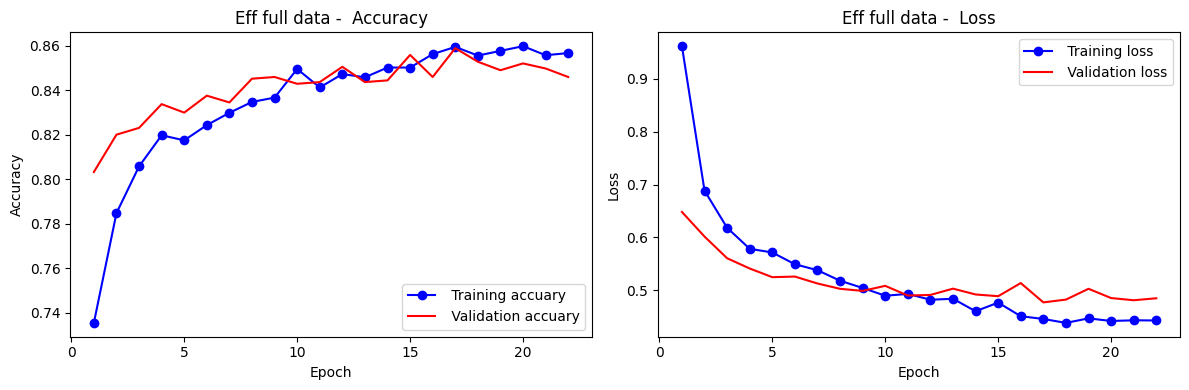

In [108]:
# Training the full dataset
eff_history_l = eff_model.fit(
    full_train_data,
    validation_data = full_val_data,
    callbacks = [early_stop],
    epochs = 50,
    verbose =1
)

plot_train_hist(eff_history_l, title_prefix = "Eff full data - ")

2026-01-10 19:43:29.797974: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:43:29.798048: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB



Eff Full dataset - Classification Report

              precision    recall  f1-score   support

      Corals     0.5743    0.9508    0.7160        61
       Crabs     0.9877    1.0000    0.9938        80
     Dolphin     0.8505    0.9010    0.8750       101
         Eel     0.8046    0.7955    0.8000        88
  Jelly Fish     0.9328    0.9615    0.9470       130
     Lobster     0.9385    0.8026    0.8652        76
 Nudibranchs     0.8000    0.9180    0.8550        61
     Octopus     0.7273    0.6437    0.6829        87
     Puffers     0.8902    0.8902    0.8902        82
    Sea Rays     0.9265    0.7778    0.8456        81
    Seahorse     0.9259    0.6667    0.7752        75
        Seal     0.8983    0.8983    0.8983        59
      Sharks     0.7895    0.7895    0.7895        95
       Squid     0.8250    0.7952    0.8098        83
    Starfish     0.9375    0.9868    0.9615        76
       Whale     0.8148    0.7674    0.7904        86

    accuracy                         

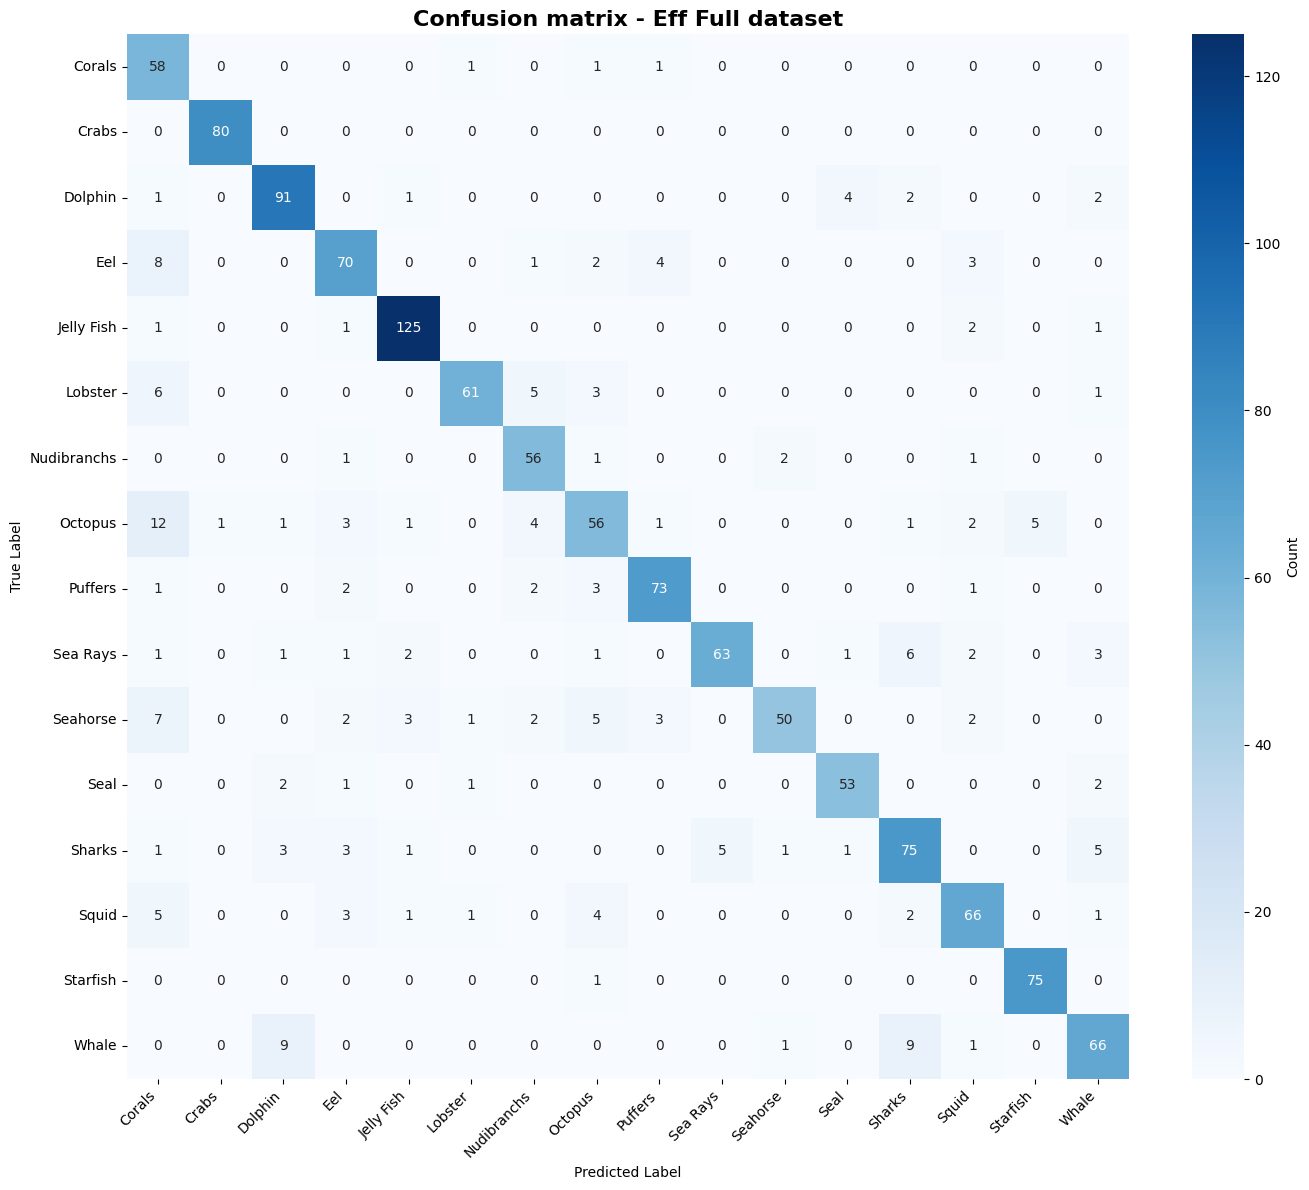


Eff Full dataset - Metrics Table
      Class  Precision  Recall  F1-score  Support
     Corals     0.5743  0.9508    0.7160       61
      Crabs     0.9877  1.0000    0.9938       80
    Dolphin     0.8505  0.9010    0.8750      101
        Eel     0.8046  0.7955    0.8000       88
 Jelly Fish     0.9328  0.9615    0.9470      130
    Lobster     0.9385  0.8026    0.8652       76
Nudibranchs     0.8000  0.9180    0.8550       61
    Octopus     0.7273  0.6437    0.6829       87
    Puffers     0.8902  0.8902    0.8902       82
   Sea Rays     0.9265  0.7778    0.8456       81
   Seahorse     0.9259  0.6667    0.7752       75
       Seal     0.8983  0.8983    0.8983       59
     Sharks     0.7895  0.7895    0.7895       95
      Squid     0.8250  0.7952    0.8098       83
   Starfish     0.9375  0.9868    0.9615       76
      Whale     0.8148  0.7674    0.7904       86

Eff Full dataset - Overall Metrics
            Metric  Score
          Accuracy 0.8463
Weighted Precision 0.8559
  

In [ ]:
# Evalaute the data
summary_eff_ft = eval_test(
    eff_model, full_test_data, class_names, name='Eff Full dataset')

- Got more training and have the best at 84%. 

- Best epochs is 17

- This is due to forzon layer

# Fine tuning

Epoch 1/50


/home/bello_the_great/Downloads/ml_cw/bello/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")
2026-01-10 19:44:02.010720: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:44:02.010946: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


  1/193 ━━━━━━━━━━━━━━━━━━━━ 1:00:55 19s/step - accuracy: 0.8750 - loss: 0.2763

2026-01-10 19:44:03.125604: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8595 - loss: 0.4287

...

193/193 ━━━━━━━━━━━━━━━━━━━━ 36s 182ms/step - accuracy: 0.8522 - loss: 0.4454 - val_accuracy: 0.8529 - val_loss: 0.4901
Epoch 5/50


2026-01-10 19:46:40.283923: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:46:40.284578: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8576 - loss: 0.4513

2026-01-10 19:47:14.333735: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:47:14.333922: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


193/193 ━━━━━━━━━━━━━━━━━━━━ 36s 182ms/step - accuracy: 0.8583 - loss: 0.4430 - val_accuracy: 0.8559 - val_loss: 0.4829
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


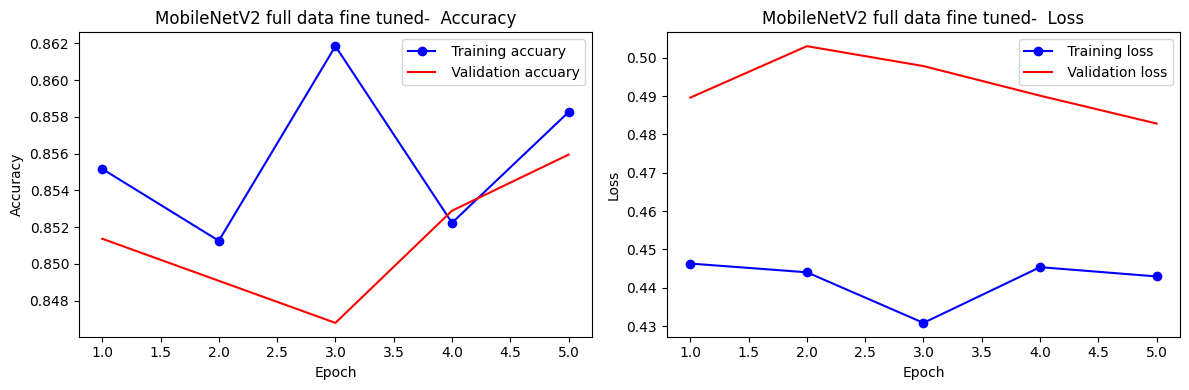

In [110]:
## Fine Tuning the dataset

# Unfreeze some layers

eff_model.trainable = True

finetune_rn = 200 # freeze the first 200 layer and the rest unforzen
for layers in eff_model.layers[:finetune_rn]:
    layers.trainable = False


eff_model.compile(
    optimizer = keras.optimizers.Adam(1e-4),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)

eff_history_ft = eff_model.fit(
    full_train_data,
    validation_data = full_val_data,
    callbacks = [early_stop],
    epochs = 50,
    verbose =1
)

plot_train_hist(eff_history_ft, title_prefix="MobileNetV2 full data fine tuned- ")

2026-01-10 19:47:16.911967: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-10 19:47:16.912054: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB



Eff Full dataset fine tuned  - Classification Report

              precision    recall  f1-score   support

      Corals     0.5700    0.9344    0.7081        61
       Crabs     0.9877    1.0000    0.9938        80
     Dolphin     0.8692    0.8857    0.8774       105
         Eel     0.7841    0.7931    0.7886        87
  Jelly Fish     0.9318    0.9609    0.9462       128
     Lobster     0.9524    0.8108    0.8759        74
 Nudibranchs     0.8026    0.9242    0.8592        66
     Octopus     0.7294    0.6667    0.6966        93
     Puffers     0.9125    0.8690    0.8902        84
    Sea Rays     0.8971    0.7531    0.8188        81
    Seahorse     0.9216    0.6812    0.7833        69
        Seal     0.9107    0.9107    0.9107        56
      Sharks     0.7857    0.7857    0.7857        98
       Squid     0.8250    0.7857    0.8049        84
    Starfish     0.9487    0.9867    0.9673        75
       Whale     0.7821    0.7625    0.7722        80

    accuracy             

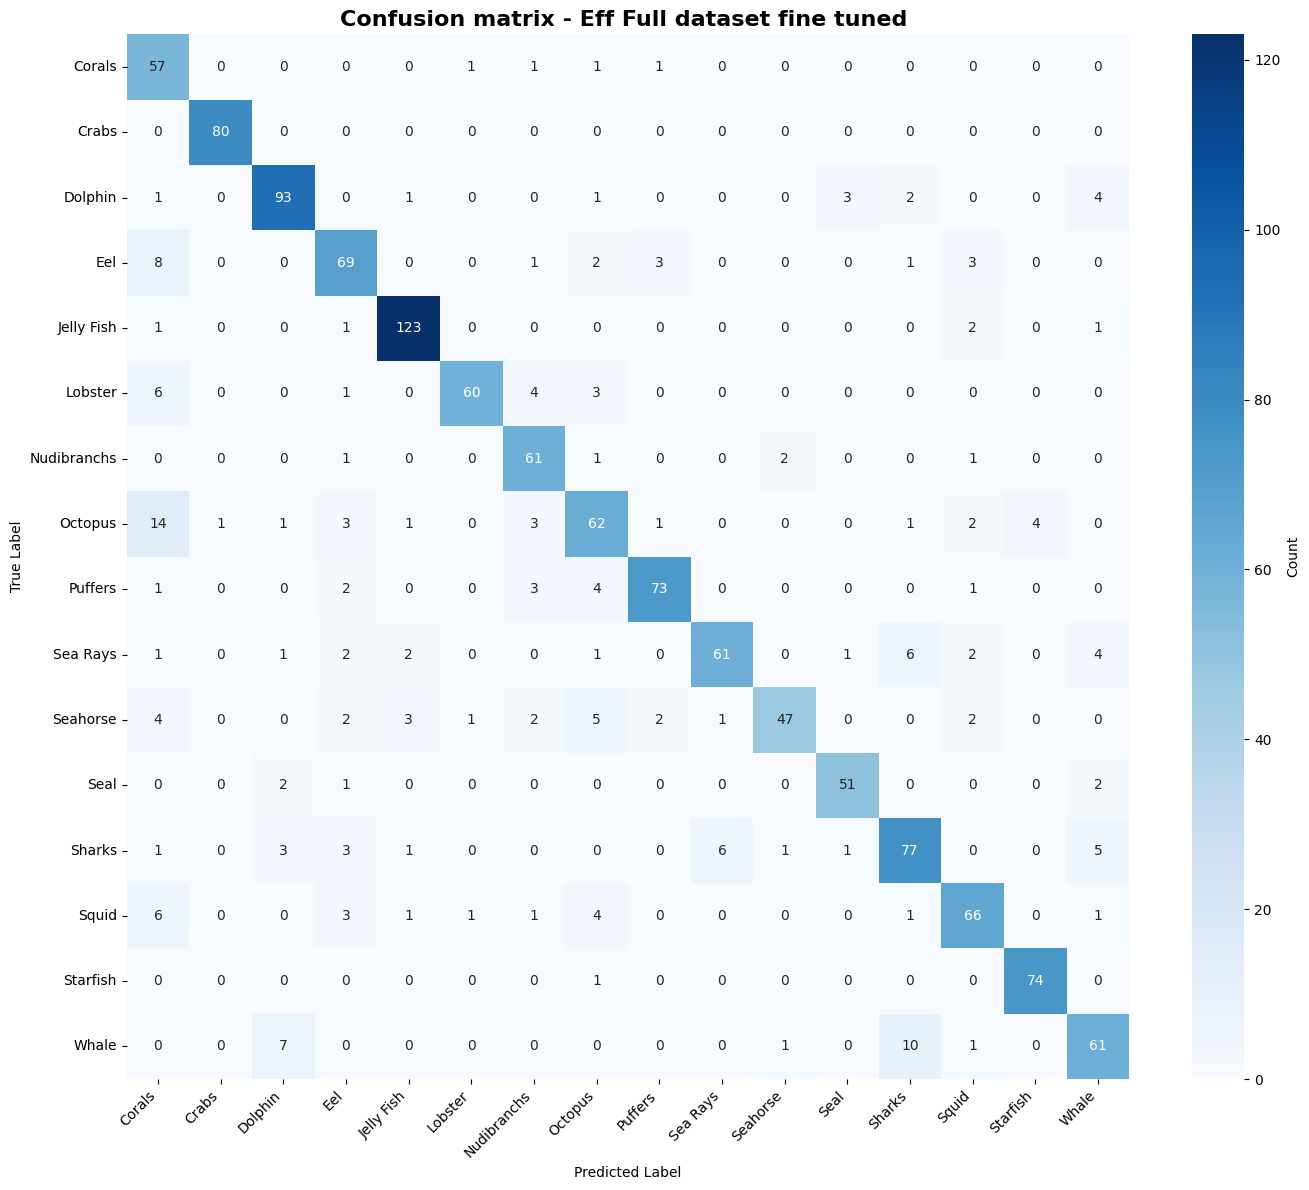


Eff Full dataset fine tuned  - Metrics Table
      Class  Precision  Recall  F1-score  Support
     Corals     0.5700  0.9344    0.7081       61
      Crabs     0.9877  1.0000    0.9938       80
    Dolphin     0.8692  0.8857    0.8774      105
        Eel     0.7841  0.7931    0.7886       87
 Jelly Fish     0.9318  0.9609    0.9462      128
    Lobster     0.9524  0.8108    0.8759       74
Nudibranchs     0.8026  0.9242    0.8592       66
    Octopus     0.7294  0.6667    0.6966       93
    Puffers     0.9125  0.8690    0.8902       84
   Sea Rays     0.8971  0.7531    0.8188       81
   Seahorse     0.9216  0.6812    0.7833       69
       Seal     0.9107  0.9107    0.9107       56
     Sharks     0.7857  0.7857    0.7857       98
      Squid     0.8250  0.7857    0.8049       84
   Starfish     0.9487  0.9867    0.9673       75
      Whale     0.7821  0.7625    0.7722       80

Eff Full dataset fine tuned  - Overall Metrics
            Metric  Score
          Accuracy 0.8441
Weig

In [ ]:
# Evalaute the data
summary_eff_ft = eval_test(
    eff_model, full_test_data, class_names, name='Eff Full dataset fine tuned ')

- The best epochs is 1 and the accuarcy is still 84%

- It got fewer training compared to the full data

## Saving and running the model

In [113]:
import os

# Save it to local device

models_dir = os.path.join('.', 'models')
os.makedirs(models_dir, exist_ok= True)

cnn_path = os.path.join(models_dir, 'cnn_baseline.keras')
mobile_path = os.path.join(models_dir, 'mobile.keras')
net_path = os.path.join(models_dir, 'resnet.keras')
eff_path = os.path.join(models_dir, 'effnet.keras')


base_model_full.save(cnn_path)
res_model.save(net_path)
model_mobile.save(mobile_path)
eff_model.save(eff_path)

print('Models are in current:', os.getcwd())

Models are in current: /home/bello_the_great/Downloads/ml_cw


## Predict an img

In [114]:
from tensorflow.keras.preprocessing import image

def predi_img(model, img_path, model_type='cnn'):
    ''' Predict an Image using cnn, mobile and resnet50 and confidence score '''
    img = image.load_img(img_path, target_size= IMG_SIZE[:2])
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    if model_type == "cnn":
        #cnn has rescaling layer in the model
        pass
    elif model_type == "mobile":
        img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    elif model_type == "resnet":
        img_array = tf.keras.applications.resnet50.preprocess_input(img_array)
    elif model_type == "eff":
        img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)
    else:
        raise ValueError(" model must be cnn, mobile or resnet or eff " )


    preds = model.predict(img_array, verbose = 0)
    pred_idx = np.argmax(preds[0])
    pred_class = class_names[pred_idx]
    confidence = float(preds[0][pred_idx])
    return pred_class, confidence

In [115]:
data_dir_local = data_dir

ex_class = class_names[6]
ex_class_dir = os.path.join(data_dir_local, ex_class)
ex_class_imgname = os.listdir(ex_class_dir)[0]
ex_img_path = os.path.join(ex_class_dir, ex_class_imgname)



print("Preddicted class :", ex_img_path)
print("Class :", ex_class)

Preddicted class : /home/bello_the_great/Downloads/ml_cw/COP508_Sea_Animal_dataset/Nudibranchs/4382014735_8298ef9fcb_o.jpg
Class : Nudibranchs


#### Predict the result

In [116]:
# CNN prediction


pred_cnn, conf_cnn = predi_img(
    base_model_full, ex_img_path, model_type="cnn"
)

print(f"CNN prediction : {pred_cnn}, confidence: {conf_cnn:.2f}" )

# Mobile prediction

pred_mobile, conf_mobile = predi_img(
    model_mobile, ex_img_path, model_type="mobile"
)

print(f"Mobile prediction :{pred_mobile}, confidence: {conf_mobile:.2f}" )

# ResNet prediction

pred_res, conf_res = predi_img(
    res_model, ex_img_path, model_type="resnet"
)

print(f"RestNet prediction : {pred_res}, confidence: {conf_res:.2f}" )

# Eff prediction

pred_eff, conf_eff = predi_img(
    eff_model, ex_img_path, model_type="eff"
)

print(f"Efficientv2 prediction : {pred_eff}, confidence: {conf_eff:.2f}" )

CNN prediction : Seahorse, confidence: 0.57
Mobile prediction :Jelly Fish, confidence: 0.63
RestNet prediction : Octopus, confidence: 0.59
Efficientv2 prediction : Nudibranchs, confidence: 0.95


# Summary

- EfficentNetv2 got the highest score of accuary 84% 

- Pretrained Models are better than cnn

- There are class imbalance in images like seal 414 images while Jellyfish

- Some animals like shark looked like other animals with the model is confused